# Connect 4 Training
Authors: Franco Salinas, Frank Rong, Hank Liu, Bhagya Puppala.

# Self-Play Policy Gradient Training
**Algorithm summary:**
- M1 plays games against a randomly chosen opponent M2 from the pool
- Each game produces (board, move, discounted_reward) triplets from M1's turns
- A single gradient step updates M1 to favour moves that led to wins
- Snapshots are disabled in the final run as pilot runs showed that adding M1 snapshots to the pool consistently caused performance degradation. The opponent pool remains fixed at the 5 original Project 1 models throughout training.

**Steps covered:**
- Step 2: Self-play episode generator with discounted reward computation
- Step 3: REINFORCE gradient update loop with opponent pool management

**Files required in the same folder:**
- Starting model (M1): connect4_cnn_final.h5
- Opponent pool: cnnmodel2.h5, connect4_cnn_model_full_v29.h5, connect4_cnn_final.h5, CNN_v2_deep_best.h5, dqn_final_copy.h5

**Outputs produced:**
- Best model by MCTS-500 win rate (saved automatically): M1_pg_best_overnight.keras 
- Final model after all rounds complete: M1_pg_final_overnight.keras 
- Loss and win rates per evaluation round:pg_training_log.csv
- Loss curve, MCTS win rate, and mixed opponent win rate charts: pg_training_curves.png 
- Weight snapshots every 20 rounds: pg_checkpoints/

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import random, os, csv, json
import matplotlib.pyplot as plt

2026-04-26 21:53:44.538783: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Configuration

Edit the values below before running. All other cells can be left unchanged.

**Key hyperparameters:**
- TOTAL_ROUNDS × GAMES_PER_ROUND = total games played during training
- LEARNING_RATE: smaller = more stable but slower; we use 2e-5 after observing loss drift with 5e-5 and
  oscillation at 1e-4 in an initial 300-round run
- SNAPSHOT_EVERY:how often a copy of M1 is added to the opponent pool;
  9999 round disable the snapshots

In [1]:
# ── Paths ──────────────────────────────────────────────────────────────────
M1_PATH        = "connect4_cnn_final.h5"     # fresh start — best results came from here
OPPONENT_PATHS = [
    "cnnmodel2.h5",
    "connect4_cnn_model_full_v29.h5",
    "connect4_cnn_final.h5",
    "CNN_v2_deep_best.h5",
    "dqn_final_copy.h5",
]
CHECKPOINT_DIR  = "pg_checkpoints"
LOG_FILE        = "pg_training_log.csv"
BEST_MODEL_PATH = "M1_pg_best_overnight.keras"   # separate name — never overwrites 76% model

# ── Training structure ─────────────────────────────────────────────────────
# Overnight run — fresh start from connect4_cnn_final.h5 with all fixes:
#   1. Fresh start (not from previous best) — avoids catastrophic forgetting
#   2. Transformer opponents added — diverse playing styles = richer gradients
#   3. Lower LR (2e-5) — less weight drift, more stable loss
#   4. Snapshots disabled — every snapshot addition caused degradation in prior runs
#   5. Tighter early stopping (10%) — saves best model sooner
TOTAL_ROUNDS      = 300    # peak always comes before round 100, 300 gives room
GAMES_PER_ROUND   = 60
GAMMA             = 0.99
LEARNING_RATE     = 2e-5   # reduced from 5e-5 — less loss drift
GRAD_CLIP_NORM    = 1.0

# ── Opponent pool management ───────────────────────────────────────────────
SNAPSHOT_EVERY    = 9999   # effectively disabled — snapshots hurt more than help
MAX_POOL_SIZE     = 10
RANDOM_INIT_MOVES = 5

# ── Early stopping ─────────────────────────────────────────────────────────
EARLY_STOP_DELTA  = 1   # tightened from 0.15 — stop sooner when degrading

# ── Evaluation ─────────────────────────────────────────────────────────────
EVAL_EVERY     = 20
EVAL_GAMES     = 50
MCTS_EVAL_SIMS = 500

import os
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print("Config loaded")
print(f"Training plan : {TOTAL_ROUNDS} rounds × {GAMES_PER_ROUND} games = "
      f"{TOTAL_ROUNDS * GAMES_PER_ROUND:,} total games")
print(f"Best model    : {BEST_MODEL_PATH}  (won't overwrite M1_pg_best.keras)")
print(f"LR={LEARNING_RATE}  snapshots=disabled  early_stop_delta={EARLY_STOP_DELTA:.0%}")

Config loaded
Training plan : 300 rounds × 60 games = 18,000 total games
Best model    : M1_pg_best_overnight.keras  (won't overwrite M1_pg_best.keras)
LR=2e-05  snapshots=disabled  early_stop_delta=100%


## Board Helper Functions

In [2]:
def update_board(board_temp, color, column):
    board = board_temp.copy()
    colsum = sum(abs(board[r, column]) for r in range(6))
    row = int(5 - colsum)
    if row > -0.5:
        board[row, column] = 1 if color == 'plus' else -1
    return board

def check_for_win(board, col):
    nrow, ncol = 6, 7
    colsum = sum(abs(board[r, col]) for r in range(6))
    row = int(6 - colsum)
    if row + 3 < 6:
        v = sum(board[row+i, col] for i in range(4))
        if v ==  4: return 'v-plus'
        if v == -4: return 'v-minus'
    for dc in range(4):
        c0 = col - dc
        if 0 <= c0 and c0 + 3 < ncol:
            h = sum(board[row, c0+i] for i in range(4))
            if h ==  4: return 'h-plus'
            if h == -4: return 'h-minus'
    for d in range(4):
        r0, c0 = row-d, col-d
        if 0 <= r0 and r0+3 < nrow and 0 <= c0 and c0+3 < ncol:
            dr = sum(board[r0+i, c0+i] for i in range(4))
            if dr ==  4: return 'd-plus'
            if dr == -4: return 'd-minus'
    for d in range(4):
        r0, c0 = row-d, col+d
        if 0 <= r0 and r0+3 < nrow and 0 <= c0-3 and c0 < ncol:
            dl = sum(board[r0+i, c0-i] for i in range(4))
            if dl ==  4: return 'd-plus'
            if dl == -4: return 'd-minus'
    return 'nobody'

def find_legal(board):
    return [i for i in range(7) if abs(board[0, i]) < 0.1]

def look_for_win(board_, color):
    for m in find_legal(board_):
        bt = update_board(board_.copy(), color, m)
        if check_for_win(bt, m)[2:] == color:
            return m
    return -1

def find_all_nonlosers(board, color):
    opp   = 'minus' if color == 'plus' else 'plus'
    legal = find_legal(board)
    poss  = [update_board(board, color, l) for l in legal]
    allowed = []
    for i, col in enumerate(legal):
        opp_wins = [j for j in find_legal(poss[i])
                    if check_for_win(update_board(poss[i], opp, j), j) != 'nobody']
        if not opp_wins:
            allowed.append(col)
    return allowed

def back_prop(winner, path, color0, md):
    for i, bt in enumerate(path):
        md[bt][0] += 1
        if winner[2] == color0[0]:
            md[bt][1] += (1 if i % 2 == 1 else -1)
        elif winner[2] != 'e':
            md[bt][1] += (-1 if i % 2 == 1 else 1)

def rollout(board, next_player):
    player = next_player
    while True:
        legal = find_legal(board)
        if not legal: return 'tie'
        move  = random.choice(legal)
        board = update_board(board, player, move)
        w     = check_for_win(board, move)
        if w != 'nobody': return w
        player = 'minus' if player == 'plus' else 'plus'

def mcts(board_temp, color0, nsteps):
    board = board_temp.copy()
    wc = look_for_win(board, color0)
    if wc > -0.5: return wc
    legal0 = find_all_nonlosers(board, color0) or find_legal(board)
    mcts_dict = {tuple(board.ravel()): [0, 0]}
    for _ in range(nsteps):
        color, winner = color0, 'nobody'
        bm = board.copy()
        path = [tuple(bm.ravel())]
        while winner == 'nobody':
            legal = find_legal(bm)
            if not legal:
                back_prop('tie', path, color0, mcts_dict); break
            bl = [tuple(update_board(bm, color, c).ravel()) for c in legal]
            for b in bl:
                if b not in mcts_dict: mcts_dict[b] = [0, 0]
            ucb = np.array([
                10*nsteps if mcts_dict[b][0]==0
                else mcts_dict[b][1]/mcts_dict[b][0] + 2*np.sqrt(np.log(mcts_dict[path[-1]][0])/mcts_dict[b][0])
                for b in bl])
            bm   = update_board(bm, color, legal[np.argmax(ucb)])
            path.append(tuple(bm.ravel()))
            winner = check_for_win(bm, legal[np.argmax(ucb)])
            if winner[2] == color[0]:
                back_prop(winner, path, color0, mcts_dict); break
            color = 'minus' if color == 'plus' else 'plus'
            if mcts_dict[tuple(bm.ravel())][0] == 0:
                back_prop(rollout(bm, color), path, color0, mcts_dict); break
    best_col, maxval = -1, -np.inf
    for col in legal0:
        nd = mcts_dict[tuple(update_board(board, color0, col).ravel())]
        v  = nd[1]/nd[0] if nd[0] else -np.inf
        if v > maxval: maxval, best_col = v, col
    return best_col

print("Board helpers loaded")

Board helpers loaded


## Model Architecture & Loading

In [5]:
# ── Transformer custom layer stubs ─────────────────────────────────────────
# The transformer h5 files use custom Keras layers. We register minimal stub
# versions so Keras can deserialise the model config without errors.
# The stubs don't need to be functional — load_weights() fills the real values.

class _PassThrough(tf.keras.layers.Layer):
    """Generic stub for any unrecognised custom layer."""
    def __init__(self, **kwargs): super().__init__(**kwargs)
    def call(self, x, **kw): return x
    def get_config(self): return super().get_config()

class RowColEmbedding(_PassThrough): pass
class CLSToken(_PassThrough): pass
class TakeToken0(_PassThrough): pass
class CLSTokenLayer(_PassThrough): pass
class PositionalEmbedding(_PassThrough): pass
class ExtractCLSToken(_PassThrough): pass

class TransformerBlock(tf.keras.layers.Layer):
    """Stub for TransformerBlock — passes input through unchanged."""
    def __init__(self, **kwargs): super().__init__(**kwargs)
    def call(self, x, **kw):
        return x[0] if isinstance(x, (list, tuple)) else x
    def get_config(self): return super().get_config()

TRANSFORMER_CUSTOM_OBJECTS = {
    "RowColEmbedding":    RowColEmbedding,
    "CLSToken":           CLSToken,
    "TakeToken0":         TakeToken0,
    "CLSTokenLayer":      CLSTokenLayer,
    "PositionalEmbedding": PositionalEmbedding,
    "ExtractCLSToken":    ExtractCLSToken,
    "TransformerBlock":   TransformerBlock,
}

def fix_batch_shape(cfg):
    """Rename batch_shape → batch_input_shape throughout the model config."""
    if isinstance(cfg, dict):
        if 'batch_shape' in cfg:
            cfg['batch_input_shape'] = cfg.pop('batch_shape')
        for v in cfg.values():
            fix_batch_shape(v)
    elif isinstance(cfg, list):
        for item in cfg:
            fix_batch_shape(item)
    return cfg


def build_policy_cnn(dropout=0.25, l2=1e-4, base_filters=96):
    """Standard architecture from Submission_CNN.ipynb."""
    reg = keras.regularizers.l2(l2)
    inp = keras.Input(shape=(6, 7, 2))
    x = layers.Conv2D(base_filters,      (3,3), padding="same", kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(base_filters,      (3,3), padding="same", kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(base_filters // 2, (3,3), padding="same", kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=reg)(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(7, activation="softmax")(x)
    return keras.Model(inp, out)


def build_connect4_cnn_final():
    """
    connect4_cnn_final.h5 — multi-branch CNN with parallel convolutions.
    Reconstructed from h5 weight shapes.
    """
    inp     = keras.Input(shape=(6, 7, 2), name="board_2ch")
    my_chan  = layers.Lambda(lambda x: x[..., 0:1], name="my_chan")(inp)
    opp_chan = layers.Lambda(lambda x: x[..., 1:2], name="opp_chan")(inp)
    diff     = layers.Subtract(name="diff_sub")([my_chan, opp_chan])
    x        = layers.Concatenate(axis=-1, name="add_diff")([my_chan, opp_chan, diff])

    stem = layers.Conv2D(128, (3,3), padding="same", use_bias=False,
                         activation="linear", name="conv2d_36")(x)
    stem = layers.BatchNormalization(name="batch_normalization_16")(stem)
    stem = layers.Activation("relu")(stem)

    b1 = layers.Conv2D(128, (1,4), padding="same", activation="relu", name="conv2d_37")(stem)
    b2 = layers.Conv2D(128, (4,1), padding="same", activation="relu", name="conv2d_38")(stem)
    b3 = layers.Conv2D(256, (3,3), padding="same", activation="relu", name="conv2d_39")(stem)
    b4 = layers.Conv2D(128, (4,4), padding="same", activation="relu", name="conv2d_40")(stem)
    b5 = layers.Conv2D(128, (5,5), padding="same", activation="relu", name="conv2d_41")(stem)
    merged = layers.Concatenate(axis=-1, name="concatenate_4")([b1, b2, b3, b4, b5])

    x = layers.Conv2D(256, (1,1), padding="same", use_bias=False,
                      activation="linear", name="conv2d_42")(merged)
    x = layers.BatchNormalization(name="batch_normalization_17")(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.2, name="dropout_71")(x)

    x = layers.Conv2D(256, (3,3), padding="same", use_bias=False,
                      activation="linear", name="conv2d_43")(x)
    x = layers.BatchNormalization(name="batch_normalization_18")(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(256, (3,3), padding="same", use_bias=False,
                      activation="linear", name="conv2d_44")(x)
    x = layers.BatchNormalization(name="batch_normalization_19")(x)
    x = layers.Activation("relu")(x)

    x   = layers.GlobalAveragePooling2D(name="global_average_pooling2d_4")(x)
    x   = layers.Dense(256, activation="relu",    name="dense_67")(x)
    x   = layers.Dropout(0.35,                    name="dropout_72")(x)
    out = layers.Dense(7,   activation="softmax", name="dense_68")(x)
    return keras.Model(inp, out)


def build_cnn_v2_deep():
    """
    CNN_v2_deep_best.h5 — deep Sequential CNN, 5 conv layers escalating
    128 → 128 → 256 → 256 → 512 filters, then 3 dense layers.
    Reconstructed from h5 weight shapes.
    """
    model = keras.Sequential(name="CNN_v2_deep")
    model.add(keras.Input(shape=(6, 7, 2), name="input_layer_3"))
    model.add(layers.Conv2D(128, (3,3), padding="same", activation="relu", name="conv2d_5"))
    model.add(layers.BatchNormalization(name="batch_normalization_13"))
    model.add(layers.Conv2D(128, (3,3), padding="same", activation="relu", name="conv2d_6"))
    model.add(layers.BatchNormalization(name="batch_normalization_14"))
    model.add(layers.Dropout(0.2, name="dropout_9"))
    model.add(layers.Conv2D(256, (3,3), padding="same", activation="relu", name="conv2d_7"))
    model.add(layers.BatchNormalization(name="batch_normalization_15"))
    model.add(layers.Conv2D(256, (3,3), padding="same", activation="relu", name="conv2d_8"))
    model.add(layers.BatchNormalization(name="batch_normalization_16"))
    model.add(layers.Dropout(0.2, name="dropout_10"))
    model.add(layers.Conv2D(512, (3,3), padding="same", activation="relu", name="conv2d_9"))
    model.add(layers.BatchNormalization(name="batch_normalization_17"))
    model.add(layers.Dropout(0.3, name="dropout_11"))
    model.add(layers.Flatten(name="flatten_3"))
    model.add(layers.Dense(512, activation="relu", name="dense_3"))
    model.add(layers.Dropout(0.4, name="dropout_12"))
    model.add(layers.Dense(256, activation="relu", name="dense_4"))
    model.add(layers.Dropout(0.4, name="dropout_13"))
    model.add(layers.Dense(7,   activation="softmax", name="dense_5"))
    return model


def build_dqn():
    """
    DQN model from Person 2 (dqn_final_copy.h5).
    Architecture: 3 Conv layers (64→128→128) + BatchNorm + 2 Dense layers.
    Output: 7 linear Q-values (NOT softmax probabilities).
    Reconstructed from h5 weight shapes.

    Note: when used as an opponent, Q-values are converted to a probability
    distribution via softmax before sampling — see sample_move_m2.
    """
    inp = keras.Input(shape=(6, 7, 2))
    x   = layers.Conv2D(64,  (3,3), padding="same", activation="relu", name="conv2d_12")(inp)
    x   = layers.BatchNormalization(name="batch_normalization_12")(x)
    x   = layers.Conv2D(128, (3,3), padding="same", activation="relu", name="conv2d_13")(x)
    x   = layers.BatchNormalization(name="batch_normalization_13")(x)
    x   = layers.Conv2D(128, (3,3), padding="same", activation="relu", name="conv2d_14")(x)
    x   = layers.BatchNormalization(name="batch_normalization_14")(x)
    x   = layers.Flatten()(x)
    x   = layers.Dense(256, activation="relu", name="dense_8")(x)
    x   = layers.Dense(128, activation="relu", name="dense_9")(x)
    out = layers.Dense(7,   activation="linear", name="q_values")(x)   # Q-values, not softmax
    return keras.Model(inp, out)


# ── Registry — maps filename substring → builder function ─────────────────
# Add a new entry here whenever you get a new .h5 from a teammate
CUSTOM_BUILDERS = {
    "connect4_cnn_final": build_connect4_cnn_final,
    "cnn_v2_deep":        build_cnn_v2_deep,
    "dqn_final":          build_dqn,
}

def get_custom_builder(path):
    name = os.path.basename(path).lower()
    for key, builder in CUSTOM_BUILDERS.items():
        if key in name:
            return builder
    return None


def load_any_model(path):
    """
    Load a .h5 model file robustly — 4-step fallback chain:
      1. Full saved model  (model.save())
      2. Known custom architecture  (CUSTOM_BUILDERS registry above)
      3. Config in h5 attrs  (fixes batch_shape compatibility automatically)
      4. Standard build_policy_cnn  (weights-only fallback)
    """
    import h5py

    # ── Step 1: full model load ────────────────────────────────────────────
    # Try standard load first (works for .keras and simple h5 full models)
    try:
        model = tf.keras.models.load_model(path, compile=False)
        print(f"  Full model loaded    : {path}  input={model.input_shape}")
        return model
    except Exception:
        pass

    # ── Step 1b: load with transformer custom objects ──────────────────────
    # Handles transformer h5 files that have custom layers (RowColEmbedding,
    # CLSToken, TransformerBlock etc.) — uses stub classes to satisfy Keras
    try:
        model = tf.keras.models.load_model(
            path, compile=False,
            custom_objects=TRANSFORMER_CUSTOM_OBJECTS
        )
        print(f"  Transformer model loaded: {path}  input={model.input_shape}")
        return model
    except Exception:
        pass

    # ── Step 2: known custom architecture — load weights by name ──────────
    builder = get_custom_builder(path)
    if builder:
        try:
            model = builder()
            model.load_weights(path, by_name=True, skip_mismatch=False)
            print(f"  Custom arch loaded   : {path}  input={model.input_shape}")
            return model
        except Exception as e:
            print(f"  Custom arch failed ({e}), continuing...")

    # ── Step 3: rebuild from config stored in h5 (fixes batch_shape) ──────
    try:
        with h5py.File(path, "r") as f:
            if "model_config" in f.attrs:
                cfg = json.loads(f.attrs["model_config"])
                fix_batch_shape(cfg)
                model = tf.keras.models.model_from_config(cfg)
                model.load_weights(path)
                print(f"  Config+weights loaded: {path}  input={model.input_shape}")
                return model
    except Exception as e:
        print(f"  Config load failed ({e}), trying standard architecture...")

    # ── Step 4: standard build_policy_cnn (weights-only fallback) ─────────
    try:
        model = build_policy_cnn()
        model.load_weights(path)
        print(f"  Weights-only loaded  : {path}  input={model.input_shape}")
        return model
    except Exception as e:
        raise RuntimeError(f"Could not load {path}: {e}")


def encode_board(board, my_color, model):
    """Encode board for whichever input shape the model expects."""
    b = -board if my_color == "minus" else board.copy()
    if model.input_shape[-1] == 2:
        ch0 = (b ==  1).astype(np.float32)
        ch1 = (b == -1).astype(np.float32)
        return np.stack([ch0, ch1], axis=-1).reshape(1, 6, 7, 2)
    return b.reshape(1, 6, 7, 1).astype(np.float32)

print("Architecture and loading defined")

Architecture and loading defined


## Load M1 and Build Opponent Pool

Loads M1 and all original Project 1 opponents. The pool starts with these
originals and grows as M1 snapshots are added during training (we set parameters to disable snapshots). Original
opponents are never removed, this ensures M1 always trains against a
diverse set of styles, not just recent versions of itself.

In [6]:
print("Loading M1...")

# Use load_any_model so M1 benefits from the same robust loading chain
# as opponents — handles batch_shape, custom layers, weights-only etc.
M1 = load_any_model(M1_PATH)

# Compile for PG training
M1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss="sparse_categorical_crossentropy"
)
print(f"M1 compiled ✓  input={M1.input_shape}")

# Load all original Project 1 opponents — these are NEVER removed from the pool
original_opponents = []
for path in OPPONENT_PATHS:
    try:
        opp = load_any_model(path)
        original_opponents.append(opp)
    except Exception as e:
        print(f"  Could not load {path}: {e}")

# opponent_pool starts with originals
opponent_pool = list(original_opponents)
print(f"\nOpponent pool: {len(opponent_pool)} models loaded")
print("M1 and opponents ready ")

Loading M1...


2026-04-26 21:54:14.364888: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


  Custom arch loaded   : connect4_cnn_final.h5  input=(None, 6, 7, 2)
M1 compiled ✓  input=(None, 6, 7, 2)
  Config load failed (Unknown dtype policy: DTypePolicy. Please ensure this object is passed to the `custom_objects` argument. See https://www.tensorflow.org/guide/keras/save_and_serialize#registering_the_custom_object for details.), trying standard architecture...
  Weights-only loaded  : cnnmodel2.h5  input=(None, 6, 7, 2)
  Full model loaded    : connect4_cnn_model_full_v29.h5  input=(None, 6, 7, 1)
  Custom arch loaded   : connect4_cnn_final.h5  input=(None, 6, 7, 2)
  Custom arch loaded   : CNN_v2_deep_best.h5  input=(None, 6, 7, 2)
  Custom arch loaded   : dqn_final_copy.h5  input=(None, 6, 7, 2)

Opponent pool: 5 models loaded
M1 and opponents ready 


## Move Sampling Functions

In [7]:
def sample_move_m1(model, board, my_color, temperature=1.0):
    """
    Stochastic sampling from M1 — legal moves only.
    Required for policy gradients (never use argmax during training).
    """
    encoded = encode_board(board, my_color, model)
    logits  = model(encoded, training=False).numpy().flatten()
    legal   = find_legal(board)
    if not legal: return None
    masked  = np.full(7, -np.inf)
    for c in legal: masked[c] = logits[c] / temperature
    lx = masked[legal] - masked[legal].max()
    p  = np.exp(lx); p /= p.sum()
    return np.random.choice(legal, p=p)


def is_dqn_model(model):
    """
    Check if this model outputs Q-values (linear) rather than probabilities (softmax).
    DQN outputs require softmax conversion before sampling.
    """
    last_layer = model.layers[-1]
    cfg = last_layer.get_config()
    activation = cfg.get("activation", "")
    # Handle both string and dict activation configs
    if isinstance(activation, dict):
        activation = activation.get("class_name", "")
    return str(activation).lower() in ("linear", "none", "")


def sample_move_m2(model, board, my_color, temperature=2.0):
    """
    Sampling for M2 opponents with temperature=2.0.

    Why temperature=2.0:
    All opponent neural nets beat M1 ~90% at temperature=1.0, producing
    almost entirely negative rewards and weak gradient signal. Temperature=2.0
    softens M2's strategy (flatter distribution), bringing M1's win rate
    to ~30-50% — the ideal range for REINFORCE learning.
    M2 still uses look_for_win and find_all_nonlosers for immediate tactics.

    DQN handling:
    The DQN outputs raw Q-values (linear activation), not probabilities.
    We apply softmax to convert Q-values to a probability distribution
    before sampling. The temperature is applied before softmax.
    """
    # M2 still plays tactically — wins immediately, blocks immediate losses
    wc = look_for_win(board, my_color)
    if wc > -0.5: return wc
    legal = find_all_nonlosers(board, my_color) or find_legal(board)

    encoded = encode_board(board, my_color, model)
    logits  = model(encoded, training=False).numpy().flatten()

    # DQN outputs Q-values — apply softmax to convert to probabilities
    # Policy models already output softmax, so this is a no-op for them
    if is_dqn_model(model):
        # Shift for numerical stability before softmax
        logits = logits - logits.max()
        logits = np.exp(logits)
        logits = logits / logits.sum()

    masked = np.full(7, -np.inf)
    for c in legal: masked[c] = logits[c] / temperature
    lx = masked[legal] - masked[legal].max()
    p  = np.exp(lx); p /= p.sum()
    return np.random.choice(legal, p=p)


def greedy_move_eval(model, board, my_color):
    """Greedy — for evaluation only, not training."""
    encoded = encode_board(board, my_color, model)
    logits  = model(encoded, training=False).numpy().flatten()
    legal   = find_legal(board)
    return legal[np.argmax([logits[c] for c in legal])]

print("  Sampling functions defined")
print("  M2 temperature=2.0 — softened to give M1 more winnable training games")
print("  DQN opponent detected automatically via output activation check")

  Sampling functions defined
  M2 temperature=2.0 — softened to give M1 more winnable training games
  DQN opponent detected automatically via output activation check


## Step 2 — Self-Play Episode Generator

In [10]:
def play_episode(M1, M2, m1_color, m2_color):
    """
    Play one game. Returns (triplets, outcome) where:
      triplets : list of (board, move, G_t) for M1's turns only
      outcome  : 'win', 'loss', or 'draw' from M1's perspective
    """
    board   = np.zeros((6, 7), dtype=np.float32)
    current = 'plus'
    episode = []

    # Random init: play 0–RANDOM_INIT_MOVES moves, do NOT record them
    n_init = random.randint(0, RANDOM_INIT_MOVES)
    for _ in range(n_init):
        legal = find_legal(board)
        if not legal: break
        move    = random.choice(legal)
        board   = update_board(board, current, move)
        if check_for_win(board, move) != 'nobody':
            return [], 'draw'
        current = 'minus' if current == 'plus' else 'plus'

    # Main game loop
    while True:
        legal = find_legal(board)
        if not legal:
            result = 'draw'; break

        if current == m1_color:
            move = sample_move_m1(M1, board, my_color=m1_color)
            episode.append((board.copy(), move, m1_color))
        else:
            move = sample_move_m2(M2, board, my_color=m2_color)

        board   = update_board(board, current, move)
        outcome = check_for_win(board, move)
        if outcome != 'nobody':
            result = 'plus' if outcome[2] == 'p' else 'minus'
            break
        current = 'minus' if current == 'plus' else 'plus'

    # Outcome from M1's perspective
    if result == 'draw':
        terminal_reward = 0.0
        m1_outcome      = 'draw'
    elif result == m1_color:
        terminal_reward = 1.0
        m1_outcome      = 'win'
    else:
        terminal_reward = -1.0
        m1_outcome      = 'loss'

    # Compute discounted returns backwards through M1's moves
    triplets = []
    G = 0.0
    for board_snap, move, _ in reversed(episode):
        G = terminal_reward + GAMMA * G
        terminal_reward = 0.0
        triplets.append((board_snap, move, G))
    triplets.reverse()
    return triplets, m1_outcome


def collect_triplets(M1, M2, n_games):
    """
    Play n_games against M2, randomly assigning who goes first each game.
    Returns:
      all_triplets : combined (board, move, G_t) triplets from all games
      win_rate     : M1 win rate against M2 over these n_games
    """
    all_triplets = []
    wins, draws, losses = 0, 0, 0

    for _ in range(n_games):
        if random.random() < 0.5:
            m1_color, m2_color = 'plus', 'minus'
        else:
            m1_color, m2_color = 'minus', 'plus'

        triplets, outcome = play_episode(M1, M2, m1_color, m2_color)
        all_triplets.extend(triplets)

        if   outcome == 'win':  wins   += 1
        elif outcome == 'draw': draws  += 1
        else:                   losses += 1

    n = max(n_games, 1)
    win_rate = wins / n
    return all_triplets, win_rate, wins, draws, losses

print(" Episode generator defined")

 Episode generator defined


## Step 3 — Policy Gradient (REINFORCE) Update

In [12]:
def prepare_batch_all(triplets, model):
    """
    Use ALL collected triplets — no random sampling.
    Matches the professor's approach: model.fit on the full episode data
    with sample_weight = discounted returns.

    Reward normalisation (zero mean, unit variance) is critical here:
    Without it, sparse_categorical_crossentropy with negative sample_weights
    becomes unbounded as the model gets more confident — π(a|s) → 0 for
    losing moves means -log(π) → ∞, causing the loss to diverge to -∞
    even when the model isn't improving. Normalisation keeps gradients
    stable and the loss bounded throughout training.
    """
    boards  = np.array([encode_board(b, 'plus', model).squeeze(0)
                        for b, _, _ in triplets], dtype=np.float32)
    moves   = np.array([mv for _, mv, _ in triplets], dtype=np.int32)
    rewards = np.array([g  for _, _,  g in triplets], dtype=np.float32)

    # Normalise rewards — zero mean, unit variance
    # This keeps the weighted cross-entropy loss bounded and gradients stable
    if rewards.std() > 1e-6:
        rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-8)

    return boards, moves, rewards


def pg_train_step_all(boards, moves, rewards):
    """
    Single PG update using model.fit on ALL collected triplets.
    sample_weight = normalised G_t implements the REINFORCE loss.
    Returns the training loss.
    """
    history = M1.fit(
        boards, moves,
        sample_weight=rewards,
        epochs=1,
        verbose=0,
        batch_size=len(moves)   # one pass over all data
    )
    return history.history["loss"][0]

print("  PG loss and update defined")
print("  Using ALL triplets + reward normalisation to prevent loss divergence")

  PG loss and update defined
  Using ALL triplets + reward normalisation to prevent loss divergence


## Evaluation Against MCTS

In [13]:
def evaluate_vs_mcts(model, n_games=EVAL_GAMES, mcts_sims=MCTS_EVAL_SIMS):
    """Play n_games vs MCTS, alternating first/second. Returns win rate."""
    wins, draws, losses = 0, 0, 0
    for i in range(n_games):
        board   = np.zeros((6, 7), dtype=np.float32)
        m_color = 'plus' if i % 2 == 0 else 'minus'
        o_color = 'minus' if m_color == 'plus' else 'plus'
        current = 'plus'

        while True:
            legal = find_legal(board)
            if not legal: draws += 1; break

            if current == m_color:
                move = greedy_move_eval(model, board, m_color)
            else:
                move = mcts(board, o_color, mcts_sims)

            board   = update_board(board, current, move)
            outcome = check_for_win(board, move)

            if outcome != 'nobody':
                wc = 'plus' if outcome[2] == 'p' else 'minus'
                if wc == m_color: wins   += 1
                else:             losses += 1
                break
            current = 'minus' if current == 'plus' else 'plus'

    wr = wins / n_games
    print(f"    Eval vs MCTS-{mcts_sims}: {wins}W {draws}D {losses}L  win rate={wr:.1%}")
    return wr

print(" Evaluation helper defined")

 Evaluation helper defined


## Mixed Opponent Evaluation

In [14]:
def evaluate_vs_mixed_opponents(model, opponents, n_games=100, temperature=2.0):
    """
    Evaluate M1 against a random mix of opponents using stochastic sampling.
    Mirrors Person 2's DQN evaluation: random.choice(all_opponents) with
    use_best=False (stochastic opponent moves, not greedy).

    Args:
        model     : M1 model to evaluate
        opponents : list of opponent models (original CNNs + any snapshots)
        n_games   : number of games to play
        temperature: opponent sampling temperature (2.0 matches training)

    Returns: win rate (float)
    """
    wins, draws, losses = 0, 0, 0

    for i in range(n_games):
        # Randomly pick an opponent each game — same as DQN teammate's approach
        opp = random.choice(opponents)

        # Alternate who goes first each game for a fair evaluation
        m1_color  = 'plus' if i % 2 == 0 else 'minus'
        opp_color = 'minus' if m1_color == 'plus' else 'plus'
        current   = 'plus'
        board     = np.zeros((6, 7), dtype=np.float32)

        while True:
            legal = find_legal(board)
            if not legal:
                draws += 1; break

            if current == m1_color:
                # M1 plays greedy (best move) during evaluation
                move = greedy_move_eval(model, board, m1_color)
            else:
                # Opponent plays stochastically — matches DQN's use_best=False
                # Still uses look_for_win/nonlosers for immediate tactics
                wc = look_for_win(board, opp_color)
                if wc > -0.5:
                    move = wc
                else:
                    opp_legal = find_all_nonlosers(board, opp_color) or find_legal(board)
                    enc    = encode_board(board, opp_color, opp)
                    logits = opp(enc, training=False).numpy().flatten()
                    # Handle DQN opponents (linear output) vs policy nets (softmax)
                    if is_dqn_model(opp):
                        logits = logits - logits.max()
                        logits = np.exp(logits)
                        logits = logits / logits.sum()
                    masked = np.full(7, -np.inf)
                    for c in opp_legal: masked[c] = logits[c] / temperature
                    lx = masked[opp_legal] - masked[opp_legal].max()
                    p  = np.exp(lx); p /= p.sum()
                    move = np.random.choice(opp_legal, p=p)

            board   = update_board(board, current, int(move))
            outcome = check_for_win(board, int(move))

            if outcome != 'nobody':
                wc = 'plus' if outcome[2] == 'p' else 'minus'
                if wc == m1_color: wins   += 1
                else:              losses += 1
                break

            current = 'minus' if current == 'plus' else 'plus'

    wr = wins / n_games
    print(f"    Eval vs mixed opponents ({len(opponents)} models, stochastic): "
          f"{wins}W {draws}D {losses}L  win rate={wr:.1%}")
    return wr


# ── Quick comparison run — call this any time to compare with DQN teammate ──
def compare_with_dqn(model, opponents, n_games=100):
    """
    Run both evaluation methods and print a side-by-side comparison.
    Call this after training completes to get numbers comparable to
    Person 2's reported ~60% win rate.
    """
    print("\nEvaluation comparison:")
    print("-" * 50)
    wr_mcts  = evaluate_vs_mcts(model, n_games=n_games, mcts_sims=500)
    wr_mixed = evaluate_vs_mixed_opponents(model, opponents, n_games=n_games)
    print(f"\n  vs MCTS-500 (objective benchmark): {wr_mcts:.1%}")
    print(f"  vs mixed CNNs (same as DQN eval)  : {wr_mixed:.1%}")
    print(f"  DQN teammate reported             : ~60%")
    return wr_mcts, wr_mixed

print("  Mixed opponent evaluation defined")
print("  Call compare_with_dqn(M1, original_opponents) after training to compare with DQN")

  Mixed opponent evaluation defined
  Call compare_with_dqn(M1, original_opponents) after training to compare with DQN


## Training Loop

In [24]:
# Initialise log file
with open(LOG_FILE, "w", newline="") as f:
    csv.writer(f).writerow([
        "round", "pg_loss", "n_triplets",
        "opp_win_rate", "opp_wins", "opp_draws", "opp_losses",
        "win_rate_vs_mcts", "avg_game_length", "opponent_index", "pool_size"
    ])

loss_history    = []
winrate_history = []
opp_wr_history  = []
best_wr_so_far  = 0.0

print(f"Starting PG training")
print(f"  {TOTAL_ROUNDS} rounds × {GAMES_PER_ROUND} games = "
      f"{TOTAL_ROUNDS * GAMES_PER_ROUND:,} total games")
print(f"  lr={LEARNING_RATE}  γ={GAMMA}  snapshot_every={SNAPSHOT_EVERY}")
print(f"  Using ALL triplets per round (professor's approach — no data wasted)")
print(f"  Checkpoints → {CHECKPOINT_DIR}/")
print("=" * 60)

for round_num in range(1, TOTAL_ROUNDS + 1):

    # ── Pick one random opponent from the pool ────────────────────────────
    # Spec: "randomly choose a different random model M2"
    opp_idx = random.randrange(len(opponent_pool))
    M2      = opponent_pool[opp_idx]

    # ── Play GAMES_PER_ROUND games, collect ALL triplets ──────────────────
    triplets, opp_wr, opp_w, opp_d, opp_l = collect_triplets(M1, M2, GAMES_PER_ROUND)
    opp_wr_history.append(opp_wr)

    if not triplets:
        continue

    # ── PG gradient step using ALL triplets (professor's approach) ────────
    boards, moves, rewards = prepare_batch_all(triplets, M1)
    loss = pg_train_step_all(boards, moves, rewards)
    loss_history.append(loss)

    # ── Print progress every 5 rounds ─────────────────────────────────────
    if round_num % 5 == 0:
        recent_loss   = np.mean(loss_history[-20:])
        recent_opp_wr = np.mean(opp_wr_history[-20:])
        print(f"Round {round_num:4d}/{TOTAL_ROUNDS}  "
              f"loss={recent_loss:.4f}  "
              f"triplets={len(triplets)}  "
              f"vs_opponent={recent_opp_wr:.1%}  "
              f"opp_idx={opp_idx}  pool={len(opponent_pool)}")

    # ── Checkpoint + evaluation every EVAL_EVERY rounds ───────────────────
    if round_num % EVAL_EVERY == 0:
        ckpt = os.path.join(CHECKPOINT_DIR, f"M1_round{round_num}.weights.h5")
        M1.save_weights(ckpt)

        mcts_wr  = evaluate_vs_mcts(M1, n_games=EVAL_GAMES, mcts_sims=MCTS_EVAL_SIMS)
        mixed_wr = evaluate_vs_mixed_opponents(M1, original_opponents,
                                               n_games=EVAL_GAMES, temperature=2.0)
        avg_len = len(triplets) / GAMES_PER_ROUND
        winrate_history.append((round_num, mcts_wr))

        # Save best model automatically
        if mcts_wr > best_wr_so_far:
            best_wr_so_far = mcts_wr
            M1.save(BEST_MODEL_PATH)
            print(f"  ★ New best (MCTS-{MCTS_EVAL_SIMS}): {mcts_wr:.1%} | vs mixed: {mixed_wr:.1%} — saved {BEST_MODEL_PATH}")

        # Early stopping — prevent wasting time on a degrading model
        # Triggers if win rate drops more than EARLY_STOP_DELTA below best
        if best_wr_so_far > 0 and mcts_wr < best_wr_so_far - EARLY_STOP_DELTA:
            print(f"\n  ⚠ Early stopping triggered at round {round_num}")
            print(f"  Current win rate {mcts_wr:.1%} is {best_wr_so_far - mcts_wr:.0%} below best {best_wr_so_far:.1%}")
            print(f"  Best model already saved → {BEST_MODEL_PATH}")
            break

        with open(LOG_FILE, "a", newline="") as f:
            csv.writer(f).writerow([
                round_num,
                round(float(np.mean(loss_history[-EVAL_EVERY:])), 6),
                len(triplets),
                round(opp_wr, 4), opp_w, opp_d, opp_l,
                round(mcts_wr, 4),
                round(avg_len, 2),
                opp_idx,
                len(opponent_pool)
            ])

    # ── Add M1 snapshot to opponent pool every SNAPSHOT_EVERY rounds ──────
    if round_num % SNAPSHOT_EVERY == 0:
        snapshot = tf.keras.models.clone_model(M1)
        snapshot.set_weights(M1.get_weights())
        n_orig = len(original_opponents)
        if len(opponent_pool) < MAX_POOL_SIZE:
            opponent_pool.append(snapshot)
            print(f"  Snapshot added → pool size: {len(opponent_pool)}")
        else:
            replace_idx = random.randint(n_orig, len(opponent_pool) - 1)
            opponent_pool[replace_idx] = snapshot
            print(f"  Snapshot replaced pool[{replace_idx}] → pool size: {len(opponent_pool)}")

print("\n" + "=" * 60)
print("Training complete!")
if winrate_history:
    best_round, best_wr = max(winrate_history, key=lambda x: x[1])
    print(f"Best win rate vs MCTS-{MCTS_EVAL_SIMS} : {best_wr:.1%} at round {best_round}")
    print(f"Final win rate vs MCTS-{MCTS_EVAL_SIMS}: {winrate_history[-1][1]:.1%}")
    print(f"Avg win rate vs opponents (last 20 rounds): "
          f"{np.mean(opp_wr_history[-20:]):.1%}")

Starting PG training
  300 rounds × 60 games = 18,000 total games
  lr=2e-05  γ=0.99  snapshot_every=9999
  Using ALL triplets per round (professor's approach — no data wasted)
  Checkpoints → pg_checkpoints/
Round    5/300  loss=-0.2265  triplets=482  vs_opponent=10.7%  opp_idx=4  pool=5
Round   10/300  loss=-0.1972  triplets=458  vs_opponent=10.0%  opp_idx=1  pool=5
Round   15/300  loss=-0.2027  triplets=556  vs_opponent=10.6%  opp_idx=4  pool=5
Round   20/300  loss=-0.2028  triplets=475  vs_opponent=10.0%  opp_idx=1  pool=5
    Eval vs MCTS-500: 31W 2D 17L  win rate=62.0%
    Eval vs mixed opponents (5 models, stochastic): 48W 1D 1L  win rate=96.0%
  ★ New best (MCTS-500): 62.0% | vs mixed: 96.0% — saved M1_pg_best_overnight.keras
Round   25/300  loss=-0.2097  triplets=500  vs_opponent=10.2%  opp_idx=1  pool=5
Round   30/300  loss=-0.2363  triplets=459  vs_opponent=10.8%  opp_idx=2  pool=5
Round   35/300  loss=-0.2488  triplets=500  vs_opponent=9.8%  opp_idx=0  pool=5
Round   40/300

## Training Curves

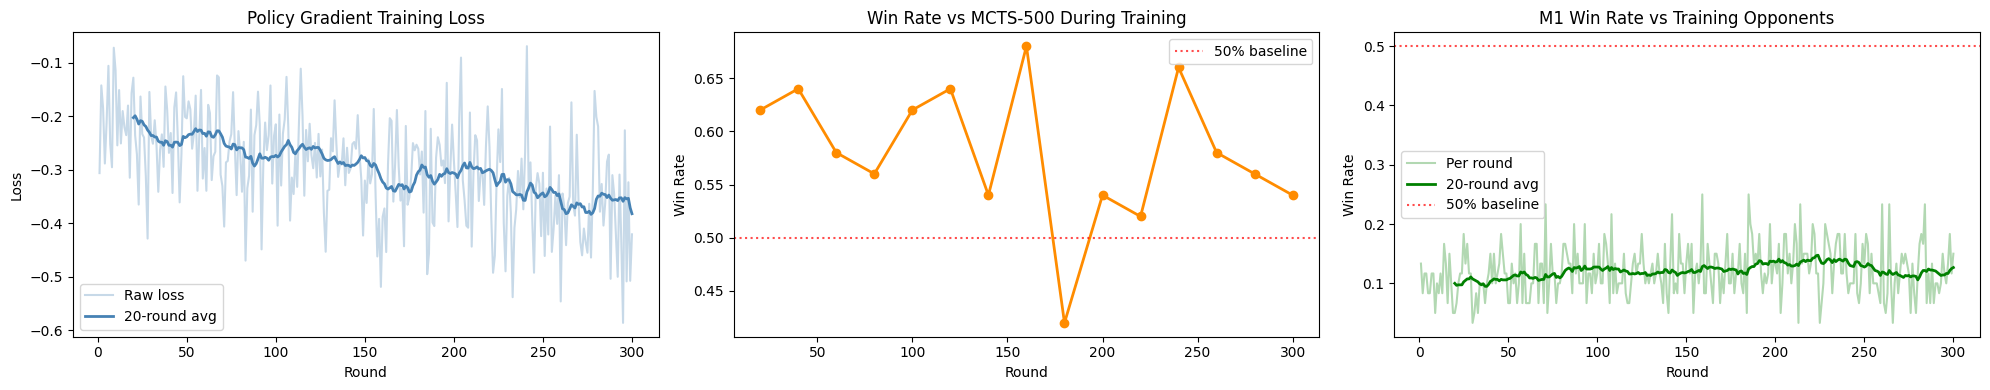

Saved → pg_training_curves.png


In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 4))

# ── Loss curve ────────────────────────────────────────────────────────────
rounds = np.arange(1, len(loss_history) + 1)
axes[0].plot(rounds, loss_history, alpha=0.3, color="steelblue", label="Raw loss")
if len(loss_history) >= 20:
    roll = np.convolve(loss_history, np.ones(20)/20, mode="valid")
    axes[0].plot(np.arange(20, len(loss_history)+1), roll,
                 color="steelblue", linewidth=2, label="20-round avg")
axes[0].set_title("Policy Gradient Training Loss")
axes[0].set_xlabel("Round"); axes[0].set_ylabel("Loss")
axes[0].legend()

# ── Win rate vs MCTS ──────────────────────────────────────────────────────
if winrate_history:
    ev_rounds = [x[0] for x in winrate_history]
    ev_wrs    = [x[1] for x in winrate_history]
    axes[1].plot(ev_rounds, ev_wrs, marker="o", color="darkorange", linewidth=2)
    for snap_round in range(SNAPSHOT_EVERY, TOTAL_ROUNDS+1, SNAPSHOT_EVERY):
        axes[1].axvline(snap_round, color="gray", linestyle="--", alpha=0.5,
                        label="Snapshot" if snap_round == SNAPSHOT_EVERY else "")
    axes[1].axhline(0.5, color="red", linestyle=":", alpha=0.7, label="50% baseline")
    axes[1].set_title(f"Win Rate vs MCTS-{MCTS_EVAL_SIMS} During Training")
    axes[1].set_xlabel("Round"); axes[1].set_ylabel("Win Rate")
    axes[1].legend()

# ── Win rate vs opponent (per round + rolling avg) ────────────────────────
if opp_wr_history:
    opp_rounds = np.arange(1, len(opp_wr_history) + 1)
    axes[2].plot(opp_rounds, opp_wr_history, alpha=0.3, color="green", label="Per round")
    if len(opp_wr_history) >= 20:
        roll_opp = np.convolve(opp_wr_history, np.ones(20)/20, mode="valid")
        axes[2].plot(np.arange(20, len(opp_wr_history)+1), roll_opp,
                     color="green", linewidth=2, label="20-round avg")
    axes[2].axhline(0.5, color="red", linestyle=":", alpha=0.7, label="50% baseline")
    axes[2].set_title("M1 Win Rate vs Training Opponents")
    axes[2].set_xlabel("Round"); axes[2].set_ylabel("Win Rate")
    axes[2].legend()

plt.tight_layout()
plt.savefig("pg_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → pg_training_curves.png")

## Results & Deliverables

In [26]:
# Save the final model (end of training)
M1.save("M1_pg_final_overnight.keras")
print("Saved → M1_pg_final.keras  (final model after all rounds)")
print("Saved → M1_pg_best.keras   (best win rate checkpoint — use this for tournament)")

# Training summary for Person 4's handoff note
if winrate_history:
    best_round, best_wr = max(winrate_history, key=lambda x: x[1])
    print(f"\nTraining summary:")
    print(f"  Total rounds     : {TOTAL_ROUNDS}")
    print(f"  Games per round  : {GAMES_PER_ROUND}")
    print(f"  Total games      : {TOTAL_ROUNDS * GAMES_PER_ROUND:,}")
    print(f"  Best win rate    : {best_wr:.1%} at round {best_round}")
    print(f"  Final win rate   : {winrate_history[-1][1]:.1%}")
    print(f"  γ={GAMMA}  α={LEARNING_RATE}  K={BATCH_SIZE}  C={SNAPSHOT_EVERY}")
    print(f"\nShare with team:")
    print(f"  → M1_pg_best.keras + pg_training_log.csv + pg_training_curves.png")

Saved → M1_pg_final.keras  (final model after all rounds)
Saved → M1_pg_best.keras   (best win rate checkpoint — use this for tournament)

Training summary:
  Total rounds     : 300
  Games per round  : 60
  Total games      : 18,000
  Best win rate    : 68.0% at round 160
  Final win rate   : 54.0%
  γ=0.99  α=2e-05  K=32  C=9999

Share with team:
  → M1_pg_best.keras + pg_training_log.csv + pg_training_curves.png


### Connect-4 DQN Training
Deep Q-Network with experience replay, target network, and epsilon-greedy annealing.
Follows the architecture of the CNN policy network but with a `tanh` output layer.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
import random
from collections import deque
import copy
import matplotlib.pyplot as plt
import os
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
# from google.colab import drive

# drive.mount('/content/drive')

# SAVE_PATH = "/content/drive/MyDrive/connect4"
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

c:\Users\Frank\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
##################################### Game Logic (from project notebook) #####################################

def update_board(board_temp, color, column):
    """Drop a piece into `column` for `color` ('plus'=+1, 'minus'=-1)."""
    board = board_temp.copy()
    colsum = np.sum(np.abs(board[:, column]))
    row = int(5 - colsum)
    if row > -0.5:
        board[row, column] = 1 if color == 'plus' else -1
    return board

def find_legal(board):
    """Return list of columns that are not full."""
    return [i for i in range(7) if abs(board[0, i]) < 0.1]

def check_for_win(board, col):
    """Return win/tie status after a piece was dropped in `col`."""
    colsum = np.sum(np.abs(board[:, col]))
    row = int(6 - colsum)

    # Vertical
    if row + 3 < 6:
        vert = sum(board[row + k, col] for k in range(4))
        if vert == 4:  return 'v-plus'
        if vert == -4: return 'v-minus'

    # Horizontal
    for sc in [col-3, col-2, col-1, col]:
        if 0 <= sc <= 3:
            h = sum(board[row, sc+k] for k in range(4))
            if h == 4:  return 'h-plus'
            if h == -4: return 'h-minus'

    # Diagonal down-right
    for offset in range(-3, 1):
        r, c = row + offset, col + offset
        if 0 <= r <= 2 and 0 <= c <= 3:
            DR = sum(board[r+k, c+k] for k in range(4))
            if DR == 4:  return 'd-plus'
            if DR == -4: return 'd-minus'

    # Diagonal down-left
    for offset in range(-3, 1):
        r, c = row + offset, col - offset
        if 0 <= r <= 2 and 3 <= c <= 6:
            DL = sum(board[r+k, c-k] for k in range(4))
            if DL == 4:  return 'd-plus'
            if DL == -4: return 'd-minus'

    return 'nobody'

In [3]:
class CNNPlayer:
    def __init__(self, model_path):
        print(f"Loading CNN model from {model_path}...")
        self.model = keras.models.load_model(f"{model_path}", compile=False, safe_mode=False) #{SAVE_PATH}/
        # Detect input channels from the model's expected input shape
        self.input_channels = self.model.input_shape[-1]
        print(f"✓ CNN loaded! (input channels: {self.input_channels})")

    def board_to_input(self, board, player='plus'):
        if player == 'minus':
            board = -board

        if self.input_channels == 2:
            inp = np.zeros((1, 6, 7, 2), dtype=np.float32)
            inp[0, :, :, 0] = (board ==  1).astype(np.float32)
            inp[0, :, :, 1] = (board == -1).astype(np.float32)
        else:
            inp = board.astype(np.float32).reshape(1, 6, 7, 1)

        return inp

    def get_move(self, board, color='plus', use_best=True):
        legal = find_legal(board)
        if not legal:
            return None
        inp = self.board_to_input(board, color)
        probs = self.model.predict(inp, verbose=0)[0]
        legal_probs = np.zeros(7)
        legal_probs[legal] = probs[legal]
        #legal_probs /= (legal_probs.sum() + 1e-8)
        if use_best:
            return int(np.argmax(legal_probs))
        else:
            # Clip negatives to 0, then normalize to valid probability distribution
            legal_probs = np.clip(legal_probs, 0, None)
            total = legal_probs.sum()

            if total < 1e-8:
                # All values were negative — fall back to uniform random over legal moves
                return random.choice(legal)

            legal_probs /= total
            return int(np.random.choice(7, p=legal_probs))

In [4]:
##################################### DQN Architecture ################################################

def build_dqn(input_shape=(6, 7, 2), num_actions=7):
    """
    CNN architecture mirroring the policy-gradient network but:
      - Output activation: linear (raw Q-values, unbounded)
      - No softmax — raw Q-values, not probabilities
    FIXED: Removed tanh output activation — tanh saturates gradients and
    artificially clamps Q-values to [-1,1], distorting TD targets.
    """
    inp = keras.Input(shape=input_shape, name='board_input')

    # ── Conv block 1 ──
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)

    # ── Conv block 2 ──
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # ── Conv block 3 ──
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)

    # ── Flatten & Dense ──
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)

    # ── Q-value head: LINEAR (no activation) so TD targets are unconstrained ──
    # out = layers.Dense(num_actions, activation=None, name='q_values')(x)
    out = layers.Dense(num_actions, activation='tanh', name='q_values')(x)

    model = keras.Model(inputs=inp, outputs=out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='mse'
    )
    return model

print(build_dqn().summary())


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ board_input (InputLayer)        │ (None, 6, 7, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 6, 7, 64)       │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 6, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 6, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 6, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 6, 7, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 6, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,376,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ q_values (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,634,247 (6.23 MB)

 Trainable params: 1,633,607 (6.23 MB)

 Non-trainable params: 640 (2.50 KB)

None


In [5]:
##################################### Experience Replay Buffer ########################################

class ReplayBuffer:
    """
    Circular buffer storing (state, action, reward, next_state, done) tuples.
    `next_state` is the board on the DQN's NEXT turn (after the opponent replies),
    not immediately after the DQN moves — per the project spec.
    """
    def __init__(self, max_size=50_000):
        self.buffer = deque(maxlen=max_size)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states,      dtype=np.float32),   # (B, 6, 7, 2)
            np.array(actions,     dtype=np.int32),      # (B,)
            np.array(rewards,     dtype=np.float32),    # (B,)
            np.array(next_states, dtype=np.float32),    # (B, 6, 7, 2)
            np.array(dones,       dtype=np.float32)     # (B,)
        )

    def __len__(self):
        return len(self.buffer)

In [7]:
##################################### Board Encoding Helper ###########################################

def encode_board(board, color='plus'):
    """
    Encode board from the perspective of `color`.
    Channel 0 = DQN's own pieces, Channel 1 = opponent pieces.
    Always encode from DQN's POV so a single model works for both colors.
    """
    if color == 'minus':
        board = -board
    encoded = np.zeros((6, 7, 2), dtype=np.float32)
    encoded[:, :, 0] = (board ==  1).astype(np.float32)   # DQN's pieces
    encoded[:, :, 1] = (board == -1).astype(np.float32)   # Opponent's pieces
    return encoded

In [6]:
##################################### DQN Agent #######################################################

class DQNAgent:
    """
    Double DQN agent with:
      - Online network  → selects actions, trained every step
      - Target network  → computes stable TD targets, synced periodically
      - Epsilon-greedy  → exploration annealed from eps_start → eps_end
    """
    def __init__(
        self,
        gamma=0.95,
        eps_start=1.0,
        eps_end=0.05,
        eps_decay=0.9995,
        batch_size=64,
        target_update_freq=500,
        buffer_size=100_000,
        min_buffer=2_000,
        double_dqn=True
    ):
        self.gamma = gamma
        self.epsilon = eps_start
        self.eps_end = eps_end
        self.eps_decay = eps_decay
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        self.min_buffer = min_buffer
        self.double_dqn = double_dqn

        self.online_net = build_dqn()
        self.target_net = build_dqn()
        self.target_net.set_weights(self.online_net.get_weights())
        # FIXED: added clipnorm to prevent exploding gradients with linear output
        self.optimizer = keras.optimizers.Adam(learning_rate=1e-4, clipnorm=10.0)
        self.buffer = ReplayBuffer(buffer_size)
        self.train_step_count = 0

    # ── Action selection ──────────────────────────────────────────────────────
    def get_move(self, board, color='plus'):
        """Epsilon-greedy action selection over legal moves only."""
        legal = find_legal(board)
        if not legal:
            return None

        if np.random.rand() < self.epsilon:
            return random.choice(legal)

        state = encode_board(board, color)[np.newaxis]   # (1, 6, 7, 2)
        q_values = self.online_net(state, training=False).numpy()[0]  # (7,)

        mask = np.full(7, -np.inf)
        mask[legal] = q_values[legal]
        return int(np.argmax(mask))

    # ── Store experience ──────────────────────────────────────────────────────
    def store(self, state, action, reward, next_state, done):
        self.buffer.push(state, action, reward, next_state, done)

    # ── Training step ─────────────────────────────────────────────────────────
    # FIXED: Removed @tf.function decorator.
    # buffer.sample() is a Python-side operation (uses random.sample on a deque).
    # Wrapping in @tf.function causes TF to try to trace Python objects as graph
    # tensors, which silently fails or produces wrong results. All TF ops inside
    # are still optimized by eager-mode XLA / GPU kernels.
    def train(self):
        if len(self.buffer) < self.min_buffer:
            return None

        states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)

        # Convert to tensors once — avoids repeated Python→TF casts
        states_tf      = tf.constant(states,      dtype=tf.float32)
        next_states_tf = tf.constant(next_states, dtype=tf.float32)
        actions_tf     = tf.constant(actions,     dtype=tf.int32)
        rewards_tf     = tf.constant(rewards,     dtype=tf.float32)
        dones_tf       = tf.constant(dones,       dtype=tf.float32)

        # ── Legal mask on next_states (top row fully empty = legal) ──────────
        # Channel 0 = DQN pieces, Channel 1 = opponent pieces; sum > 0 → occupied
        top_row = next_states[:, 0, :, 0] + next_states[:, 0, :, 1]
        legal_mask = top_row < 0.5  # shape (B, 7), True = legal

        # ── Compute TD targets (no gradient) ─────────────────────────────────
        if self.double_dqn:
            # Online net picks the action, target net evaluates it
            nq_online = self.online_net(next_states_tf, training=False).numpy()  # (B,7)
            nq_online = np.where(legal_mask, nq_online, -1e9)
            best_actions = np.argmax(nq_online, axis=1)                           # (B,)

            nq_target = self.target_net(next_states_tf, training=False).numpy()   # (B,7)
            next_q = nq_target[np.arange(self.batch_size), best_actions]          # (B,)
        else:
            nq_target = self.target_net(next_states_tf, training=False).numpy()   # (B,7)
            nq_target = np.where(legal_mask, nq_target, -1e9)
            next_q = nq_target.max(axis=1)                                        # (B,)

        td_targets = rewards + self.gamma * next_q * (1.0 - dones)
        td_targets_tf = tf.constant(td_targets, dtype=tf.float32)

        loss = self.train_step(states_tf, actions_tf, td_targets_tf)

        self.train_step_count += 1
        if self.train_step_count % self.target_update_freq == 0:
            self.target_net.set_weights(self.online_net.get_weights())

        return float(loss)

    @tf.function
    def train_step(self,states_tf, actions_tf, td_targets_tf):
        # ── Gradient step ─────────────────────────────────────────────────────
        with tf.GradientTape() as tape:
            q_all   = self.online_net(states_tf, training=True)                   # (B, 7)
            q_taken = tf.gather(q_all, actions_tf, axis=1, batch_dims=1)         # (B,)
            loss    = tf.reduce_mean(tf.square(td_targets_tf - q_taken))

        grads = tape.gradient(loss, self.online_net.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.online_net.trainable_variables))

        return loss

    def save(self, path):
        self.online_net.save(f"{path}")#{SAVE_PATH}/
        print(f"DQN saved → {path}")


In [7]:
##################################### Game Runner #####################################################

def count_threats(board, color):
    """
    Count the number of open three-in-a-rows for `color`.
    Used for lightweight reward shaping: reward blocking opponent threats
    and creating own threats, without fully solving the game.
    """
    val = 1 if color == 'plus' else -1
    count = 0
    # Horizontal
    for r in range(6):
        for c in range(4):
            window = [board[r, c+k] for k in range(4)]
            if window.count(val) == 3 and window.count(0) == 1:
                count += 1
    # Vertical
    for r in range(3):
        for c in range(7):
            window = [board[r+k, c] for k in range(4)]
            if window.count(val) == 3 and window.count(0) == 1:
                count += 1
    # Diagonal ↘
    for r in range(3):
        for c in range(4):
            window = [board[r+k, c+k] for k in range(4)]
            if window.count(val) == 3 and window.count(0) == 1:
                count += 1
    # Diagonal ↙
    for r in range(3):
        for c in range(3, 7):
            window = [board[r+k, c-k] for k in range(4)]
            if window.count(val) == 3 and window.count(0) == 1:
                count += 1
    return count


def play_dqn_game(
    dqn_agent,
    opponent,
    dqn_color='plus',
    num_random_init_moves=4,
    train_after_each_move=False,
    shaped_reward_scale=0.1    # ADDED: weight for intermediate threat rewards
):
    """
    Play one game between the DQN agent and an opponent.

    FIXES:
      - Added lightweight reward shaping: small positive reward for creating
        3-in-a-row threats, small negative for allowing opponent threats.
        Against a strong CNN, pure sparse +1/-1 is very hard to learn.
      - shaped_reward_scale=0.1 keeps shaping secondary to terminal rewards.

    Returns: reward, total_moves, losses
    """
    opp_color = 'minus' if dqn_color == 'plus' else 'plus'
    board = np.zeros((6, 7))
    winner = 'nobody'
    total_moves = 0
    losses = []

    # ── Random initialization moves (not learned from) ────────────────────────
    current_init_color = 'plus'
    for _ in range(num_random_init_moves):
        legal = find_legal(board)
        if not legal:
            break
        col = random.choice(legal)
        board = update_board(board, current_init_color, col)
        winner = check_for_win(board, col)
        if winner != 'nobody':
            return 0, total_moves, losses
        current_init_color = 'minus' if current_init_color == 'plus' else 'plus'

    total_pieces = int(np.sum(np.abs(board)))
    turn_color = 'plus' if total_pieces % 2 == 0 else 'minus'

    pending = None  # (state, action) waiting for next_state

    while winner == 'nobody':
        legal = find_legal(board)
        if not legal:
            winner = 'tie'
            break

        if turn_color == dqn_color:
            # ── DQN's turn ────────────────────────────────────────────────────
            state = encode_board(board, dqn_color)
            action = dqn_agent.get_move(board, dqn_color)

            board = update_board(board, dqn_color, action)
            winner = check_for_win(board, action)
            total_moves += 1

            if winner != 'nobody' and winner != 'tie':
                if ('plus' in winner and dqn_color == 'plus') or \
                   ('minus' in winner and dqn_color == 'minus'):
                    reward = 1.0
                else:
                    reward = -1.0

                next_state = encode_board(board, dqn_color)
                dqn_agent.store(state, action, reward, next_state, done=1.0)

                if pending is not None:
                    ps, pa = pending
                    dqn_agent.store(ps, pa, reward, next_state, done=1.0)
                    pending = None
                break
            else:
                # ADDED: shaped intermediate reward based on threat delta
                dqn_threats_after  = count_threats(board, dqn_color)
                opp_threats_after  = count_threats(board, opp_color)
                shaped = shaped_reward_scale * (dqn_threats_after - opp_threats_after)
                shaped = np.clip(shaped, -0.5, 0.5)   # cap to stay secondary
                pending = (state, action, shaped)

        else:
            # ── Opponent's turn ───────────────────────────────────────────────
            opp_action = opponent.get_move(board, opp_color, use_best=False)
            if opp_action is None:
                winner = 'tie'
                break

            board = update_board(board, opp_color, opp_action)
            winner = check_for_win(board, opp_action)
            total_moves += 1

            if pending is not None:
                ps, pa, shaped = pending
                next_state = encode_board(board, dqn_color)

                if winner == 'tie':
                    dqn_agent.store(ps, pa, 0.0, next_state, done=1.0)
                    pending = None
                    break
                elif winner != 'nobody':
                    # Opponent won → DQN loses
                    dqn_agent.store(ps, pa, -1.0, next_state, done=1.0)
                    pending = None
                    break
                else:
                    # Game continues — use shaped intermediate reward
                    dqn_agent.store(ps, pa, shaped, next_state, done=0.0)
                    pending = None

        turn_color = 'minus' if turn_color == 'plus' else 'plus'

        if train_after_each_move:
            loss = dqn_agent.train()
            if loss is not None:
                losses.append(loss)

    if winner == 'tie':
        final_reward = 0.0
    elif ('plus' in winner and dqn_color == 'plus') or \
         ('minus' in winner and dqn_color == 'minus'):
        final_reward = 1.0
    else:
        final_reward = -1.0

    return final_reward, total_moves, losses


In [8]:
def evaluate_agent(p1, p2, n_games=50):
    wins = 0
    # original_epsilon = getattr(agent_player, 'epsilon', None)
    # if original_epsilon is not None:
    #     agent_player.epsilon = 0.0

    for i in range(n_games):
        # FIXED: alternate DQN color each game for a fair evaluation
        dqn_color = 'plus' if i % 2 == 0 else 'minus'
        opp_color = 'minus' if dqn_color == 'plus' else 'plus'
        turn_color = 'plus'
        board = np.zeros((6, 7))
        winner = 'nobody'

        while winner == 'nobody':
            legal = find_legal(board)
            if not legal:
                winner = 'tie'
                break

            if turn_color == dqn_color:
                action = p1.get_move(board, dqn_color, use_best = True)
                board = update_board(board, dqn_color, action)
                winner = check_for_win(board, action)
            else:
                opp_action = p2.get_move(board, opp_color, use_best = False)
                board = update_board(board, opp_color, opp_action)
                winner = check_for_win(board, opp_action)

            turn_color = 'minus' if turn_color == 'plus' else 'plus'

        if winner == 'tie':
            reward = 0.0
        elif ('plus' in winner and dqn_color == 'plus') or \
             ('minus' in winner and dqn_color == 'minus'):
            reward = 1.0
        else:
            reward = -1.0

        if reward > 0:
            wins += 1
     # Restore epsilon after evaluation
    # if original_epsilon is not None:
    #     agent_player.epsilon = original_epsilon
    return wins / n_games

### Training Loop

In [15]:
##################################### Main Training Loop ##############################################

# ── Hyper-parameters ─────────────────────────────────────────────────────────
NUM_EPISODES         = 60000
SNAPSHOT_FREQ        = 1000
MAX_OPPONENT_COPIES  = 5
NUM_RANDOM_INIT      = 0
PRINT_FREQ           = 1000
GAMES_PER_OPPONENT   = 50

# ── Load pre-trained CNN opponents ───────────────────────────────────────────
cnn_model_paths = [
    "CNN_v2_deep_best.h5",
    "cnnmodel2.h5",
    "connect4_cnn_model_full_v29.h5"
]

base_opponents = [CNNPlayer(p) for p in cnn_model_paths]
all_opponents = list(base_opponents)

# ── DQN Agent ────────────────────────────────────────────────────────────────
agent = DQNAgent(
    gamma=0.95,
    eps_start=1,
    eps_end=0.05,
    eps_decay=0.99995,
    batch_size=64,
    target_update_freq=500,
    buffer_size=100_000,
    min_buffer=2_000,
    double_dqn=True
)

# Load the saved weights to resume training (uncomment if resuming):
agent.online_net = keras.models.load_model(f"dqn_final.h5", compile=False, safe_mode=False)#{SAVE_PATH}/
agent.target_net = keras.models.load_model(f"dqn_final.h5", compile=False, safe_mode=False)
agent.online_net.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4, clipnorm=10.0), loss='mse')
agent.target_net.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4, clipnorm=10.0), loss='mse')
agent.epsilon = 0.15   # resume with low epsilon if already well-trained
print("✓ DQN loaded and ready to resume training!")

# LOAD 5 Last MODELS
for i in [35,36,37,38,39]:
    snap_path = f"dqn_snapshot_ep{i}000.h5"
    snap_player = CNNPlayer(snap_path)
    eval_opponent = random.choice(base_opponents)  # or fix a strong opponent
    score = evaluate_agent(snap_player, eval_opponent)

        # Store (player, score)
    dqn_snaps = [(o, getattr(o, "score", None)) for o in all_opponents if o not in base_opponents]

        # Assign score to new snapshot
    snap_player.score = score
    all_opponents.append(snap_player)

# ── Tracking ──────────────────────────────────────────────────────────────────
rewards_history  = []
win_rate_history = []
loss_history     = []
eps_history      = []

win_window = deque(maxlen=1000)

print(f"Starting DQN training — {NUM_EPISODES} episodes")
print("=" * 60)
opponent = random.choice(all_opponents)

for episode in range(1, NUM_EPISODES + 1):
    if episode % GAMES_PER_OPPONENT == 0:
        opponent = random.choice(all_opponents)
    dqn_color = random.choice(['plus', 'minus'])

    reward, n_moves, ep_losses = play_dqn_game(
        dqn_agent=agent,
        opponent=opponent,
        dqn_color=dqn_color,
        num_random_init_moves=NUM_RANDOM_INIT,
        train_after_each_move=True
    )

    # ── Anneal epsilon once per episode  ──
    agent.epsilon = max(agent.eps_end, agent.epsilon * agent.eps_decay)

    rewards_history.append(reward)
    win_window.append(1 if reward > 0 else 0)
    win_rate_history.append(np.mean(win_window))
    if ep_losses:
        loss_history.append(np.mean(ep_losses))
    eps_history.append(agent.epsilon)

    if episode % PRINT_FREQ == 0:
        wr  = win_rate_history[-1]
        avg_loss = np.mean(loss_history[-PRINT_FREQ:]) if loss_history else float('nan')
        print(f"Ep {episode:5d} | WinRate(1000): {wr:.3f} | "
              f"ε: {agent.epsilon:.4f} | AvgLoss: {avg_loss:.4f} | "
              f"Buffer: {len(agent.buffer):,}")

    if episode % SNAPSHOT_FREQ == 0:
        snap_path = f"dqn_snapshot_ep{episode}.h5"
        agent.save(snap_path)
        snap_player = CNNPlayer(snap_path)

        # Evaluate new snapshot
        eval_opponent = random.choice(base_opponents)  # or fix a strong opponent
        score = evaluate_agent(snap_player, eval_opponent)

        # Store (player, score)
        dqn_snaps = [(o, getattr(o, "score", None)) for o in all_opponents if o not in base_opponents]

        # Assign score to new snapshot
        snap_player.score = score

        if len(dqn_snaps) >= MAX_OPPONENT_COPIES:
            # Find worst performing snapshot
            worst_player = min(dqn_snaps, key=lambda x: x[1])[0]
            all_opponents.remove(worst_player)

        all_opponents.append(snap_player)
        print(f"\n  → Snapshot saved: {snap_path} | Pool size: {len(all_opponents)}\n")

    # Gradually reduce random init moves so DQN faces more real openings
    #if episode == 12000 or episode == 18000 or episode == 25000:
     #   NUM_RANDOM_INIT = max(0, NUM_RANDOM_INIT - 1)

print("\nTraining complete!")
agent.save("dqn_final.h5")


Ep 44000 | WinRate(1000): 0.601 | ε: 0.0500 | AvgLoss: 0.0444 | Buffer: 100,000
DQN saved → dqn_snapshot_ep44000.h5
Loading CNN model from dqn_snapshot_ep44000.h5...
✓ CNN loaded! (input channels: 2)

  → Snapshot saved: dqn_snapshot_ep44000.h5 | Pool size: 8



Ep 45000 | WinRate(1000): 0.616 | ε: 0.0500 | AvgLoss: 0.0456 | Buffer: 100,000
DQN saved → dqn_snapshot_ep45000.h5
Loading CNN model from dqn_snapshot_ep45000.h5...
✓ CNN loaded! (input channels: 2)

  → Snapshot saved: dqn_snapshot_ep45000.h5 | Pool size: 8



Ep 46000 | WinRate(1000): 0.702 | ε: 0.0500 | AvgLoss: 0.0451 | Buffer: 100,000
DQN saved → dqn_snapshot_ep46000.h5
Loading CNN model from dqn_snapshot_ep46000.h5...
✓ CNN loaded! (input channels: 2)

  → Snapshot saved: dqn_snapshot_ep46000.h5 | Pool size: 8



Ep 47000 | WinRate(1000): 0.624 | ε: 0.0500 | AvgLoss: 0.0458 | Buffer: 100,000
DQN saved → dqn_snapshot_ep47000.h5
Loading CNN model from dqn_snapshot_ep47000.h5...
✓ CNN loaded! (input channels: 2)

  → Snapshot saved: dqn_snapshot_ep47000.h5 | Pool size: 8



Ep 48000 | WinRate(1000): 0.670 | ε: 0.0500 | AvgLoss: 0.0466 | Buffer: 100,000
DQN saved → dqn_snapshot_ep48000.h5
Loading CNN model from dqn_snapshot_ep48000.h5...
✓ CNN loaded! (input channels: 2)

  → Snapshot saved: dqn_snapshot_ep48000.h5 | Pool size: 8



...

Ep 57000 | WinRate(1000): 0.727 | ε: 0.0500 | AvgLoss: 0.0400 | Buffer: 100,000
DQN saved → dqn_snapshot_ep57000.h5
Loading CNN model from dqn_snapshot_ep57000.h5...
✓ CNN loaded! (input channels: 2)

  → Snapshot saved: dqn_snapshot_ep57000.h5 | Pool size: 8



Ep 58000 | WinRate(1000): 0.661 | ε: 0.0500 | AvgLoss: 0.0408 | Buffer: 100,000
DQN saved → dqn_snapshot_ep58000.h5
Loading CNN model from dqn_snapshot_ep58000.h5...
✓ CNN loaded! (input channels: 2)

  → Snapshot saved: dqn_snapshot_ep58000.h5 | Pool size: 8



Ep 59000 | WinRate(1000): 0.664 | ε: 0.0500 | AvgLoss: 0.0407 | Buffer: 100,000
DQN saved → dqn_snapshot_ep59000.h5
Loading CNN model from dqn_snapshot_ep59000.h5...
✓ CNN loaded! (input channels: 2)

  → Snapshot saved: dqn_snapshot_ep59000.h5 | Pool size: 8



Ep 60000 | WinRate(1000): 0.601 | ε: 0.0500 | AvgLoss: 0.0410 | Buffer: 100,000
DQN saved → dqn_snapshot_ep60000.h5
Loading CNN model from dqn_snapshot_ep60000.h5...
✓ CNN loaded! (input channels: 2)



  → Snapshot saved: dqn_snapshot_ep60000.h5 | Pool size: 8


Training complete!
DQN saved → dqn_final.h5


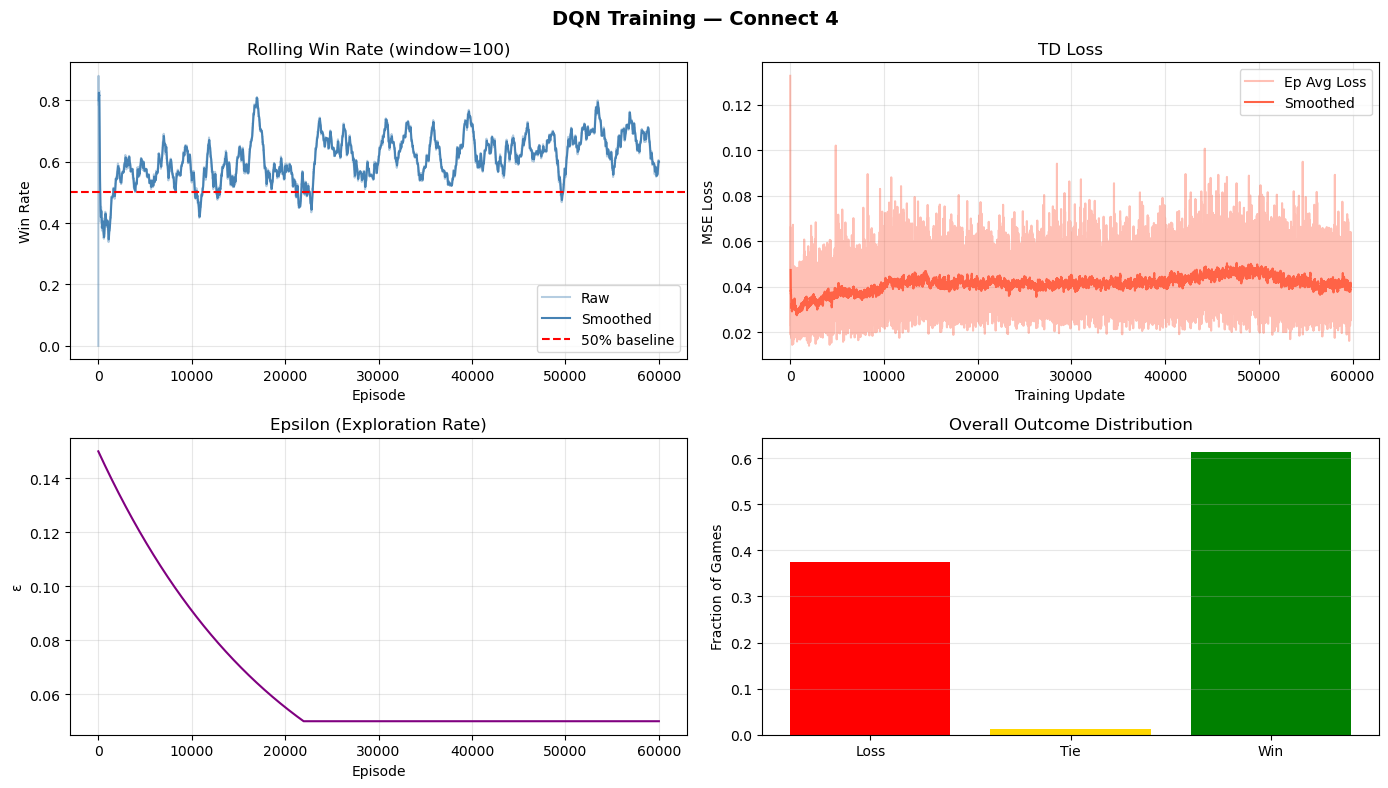

Plot saved → dqn_training_results.png


In [16]:
##################################### Training Visualizations #########################################

def smooth(arr, window=50):
    """Simple moving average for plotting."""
    return np.convolve(arr, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('DQN Training — Connect 4', fontsize=14, fontweight='bold')

# 1. Rolling win rate
ax = axes[0, 0]
ax.plot(win_rate_history, alpha=0.4, color='steelblue', label='Raw')
if len(win_rate_history) > 50:
    ax.plot(range(50, len(win_rate_history)),
            smooth(win_rate_history[1:], 50), color='steelblue', label='Smoothed')
ax.axhline(0.5, color='red', linestyle='--', label='50% baseline')
ax.set_title('Rolling Win Rate (window=100)')
ax.set_xlabel('Episode'); ax.set_ylabel('Win Rate')
ax.legend(); ax.grid(alpha=0.3)

# 2. Training loss
ax = axes[0, 1]
if loss_history:
    ax.plot(loss_history, alpha=0.4, color='tomato', label='Ep Avg Loss')
    if len(loss_history) > 50:
        ax.plot(range(50, len(loss_history)),
                smooth(loss_history[1:], 50), color='tomato', label='Smoothed')
ax.set_title('TD Loss')
ax.set_xlabel('Training Update'); ax.set_ylabel('MSE Loss')
ax.legend(); ax.grid(alpha=0.3)

# 3. Epsilon decay
ax = axes[1, 0]
ax.plot(eps_history, color='purple')
ax.set_title('Epsilon (Exploration Rate)')
ax.set_xlabel('Episode'); ax.set_ylabel('ε')
ax.grid(alpha=0.3)

# 4. Reward distribution
ax = axes[1, 1]
vals, cnts = np.unique(rewards_history, return_counts=True)
labels = {1.0: 'Win', 0.0: 'Tie', -1.0: 'Loss'}
colors = {1.0: 'green', 0.0: 'gold', -1.0: 'red'}
ax.bar([labels.get(v, str(v)) for v in vals],
       cnts / len(rewards_history),
       color=[colors.get(v, 'gray') for v in vals])
ax.set_title('Overall Outcome Distribution')
ax.set_ylabel('Fraction of Games'); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('dqn_training_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → dqn_training_results.png")

In [ ]:
##################################### Evaluation: DQN vs CNN Baseline ################################

def evaluate(dqn_agent, opponent, n_games=100, num_random_init=0):
    """
    Evaluate DQN against an opponent with epsilon=0 (fully greedy).
    Alternates who goes first each game.
    Returns: win_rate, tie_rate, loss_rate
    """
    old_eps = dqn_agent.epsilon
    dqn_agent.epsilon = 0.0   # Pure exploitation during eval

    outcomes = []
    for i in range(n_games):
        color = 'plus' if i % 2 == 0 else 'minus'
        r, _, _ = play_dqn_game(dqn_agent, opponent,
                                 dqn_color=color,
                                 num_random_init_moves=num_random_init,
                                 train_after_each_move=False)  # No training during eval
        outcomes.append(r)

    dqn_agent.epsilon = old_eps   # Restore

    outcomes = np.array(outcomes)
    wins  = np.mean(outcomes ==  1)
    ties  = np.mean(outcomes ==  0)
    losses= np.mean(outcomes == -1)
    print(f"Eval over {n_games} games → Wins: {wins:.2%}  Ties: {ties:.2%}  Losses: {losses:.2%}")
    return wins, ties, losses

# Evaluate against the original CNN baseline
print("\n── Evaluation: DQN vs original CNN ──")
m1 = CNNPlayer("dqn_snapshot_ep57000.h5")
evaluate(m1, base_opponents[0], n_games=50, num_random_init=0)

In [10]:
# for i in range(1,51):
#     board = np.zeros((6,7))
#     print(CNNPlayer(f'dqn_snapshot_ep{i}000.h5').get_move(board, color = 'plus', use_best= True))
board = np.zeros((6,7))
print(CNNPlayer(f'dqn_final_042526.h5').get_move(board, color = 'plus', use_best= True))

Loading CNN model from dqn_final_042526.h5...
✓ CNN loaded! (input channels: 2)
4


# Evaluation Infrastructure

Helpers and the comparison matrix for steps 5 and 6.


## 1. Imports

In [ ]:
import os, sys, csv, json, random, time, copy
from collections import Counter, defaultdict
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import h5py

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
tf.get_logger().setLevel("ERROR")

# Allow loading models with Lambda layers (e.g. Franco's connect4_cnn_final has
# Lambda slicers x[..., 0:1] / x[..., 1:2]). The legacy h5 path doesn't honor
# safe_mode=False so we set it globally.
keras.config.enable_unsafe_deserialization()

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

## 2. Configuration

In [ ]:
PROJECT_ROOT = "./project3"  # local path redacted for public repo — set this to your own model directory

PG_FINAL_PATH  = os.path.join(PROJECT_ROOT, "P1 deliverables", "M1_pg_best_overnight.keras")
DQN_FINAL_PATH = None
for _candidate in [
    os.path.join(PROJECT_ROOT, "P2 deliverables 3", "dqn_final_042726.h5"),
    os.path.join(PROJECT_ROOT, "P2 deliverables", "dqn_final_042726.h5"),
    os.path.join(PROJECT_ROOT, "P2 deliverables", "Copy of dqn_final.h5"),
]:
    if os.path.exists(_candidate):
        DQN_FINAL_PATH = _candidate; break
if DQN_FINAL_PATH is None:
    DQN_FINAL_PATH = os.path.join(PROJECT_ROOT, "P2 deliverables", "Copy of dqn_final.h5")

P1_BASELINES = {
    "franco_cnn":     os.path.join(PROJECT_ROOT, "cnnmodel2_franco.h5"),
    "franco_xfmer":   os.path.join(PROJECT_ROOT, "transformer2_franco.keras"),
    "hank_cnn":       os.path.join(PROJECT_ROOT, "connect4_cnn_model_full_v29_hank.h5"),
    "hank_xfmer":     os.path.join(PROJECT_ROOT, "model_transformer_best_v29_hank.h5"),
    "frank_deep_cnn": os.path.join(PROJECT_ROOT, "CNN_v2_deep_best_frank.h5"),
}

OUT_DIR = os.path.join(PROJECT_ROOT, "eval_outputs")
os.makedirs(OUT_DIR, exist_ok=True)

print(f"PG final  : {os.path.basename(PG_FINAL_PATH)}  {'OK' if os.path.exists(PG_FINAL_PATH) else 'MISSING'}")
print(f"DQN final : {os.path.basename(DQN_FINAL_PATH)}  {'OK' if os.path.exists(DQN_FINAL_PATH) else 'MISSING'}")
for k, p in P1_BASELINES.items():
    print(f"  {k:<16}: {os.path.basename(p)}  {'OK' if os.path.exists(p) else 'MISSING'}")

## 3. Board helpers and MCTS

In [ ]:
def update_board(board_temp, color, column):
    board = board_temp.copy()
    colsum = sum(abs(board[r, column]) for r in range(6))
    row = int(5 - colsum)
    if row > -0.5:
        board[row, column] = 1 if color == "plus" else -1
    return board


def check_for_win(board, col):
    nrow, ncol = 6, 7
    colsum = sum(abs(board[r, col]) for r in range(6))
    row = int(6 - colsum)

    if row + 3 < 6:
        v = board[row,col]+board[row+1,col]+board[row+2,col]+board[row+3,col]
        if v ==  4: return "v-plus"
        if v == -4: return "v-minus"

    for dc in range(4):
        c0 = col - dc
        if 0 <= c0 and c0 + 3 < ncol:
            h = board[row,c0]+board[row,c0+1]+board[row,c0+2]+board[row,c0+3]
            if h ==  4: return "h-plus"
            if h == -4: return "h-minus"

    for d in range(4):
        r0, c0 = row - d, col - d
        if 0 <= r0 and r0+3 < nrow and 0 <= c0 and c0+3 < ncol:
            dr = board[r0,c0]+board[r0+1,c0+1]+board[r0+2,c0+2]+board[r0+3,c0+3]
            if dr ==  4: return "d-plus"
            if dr == -4: return "d-minus"

    for d in range(4):
        r0, c0 = row - d, col + d
        if 0 <= r0 and r0+3 < nrow and 0 <= c0-3 and c0 < ncol:
            dl = board[r0,c0]+board[r0+1,c0-1]+board[r0+2,c0-2]+board[r0+3,c0-3]
            if dl ==  4: return "d-plus"
            if dl == -4: return "d-minus"

    return "nobody"


def find_legal(board):
    return [i for i in range(7) if abs(board[0, i]) < 0.1]


def look_for_win(board_, color):
    for m in find_legal(board_):
        bt = update_board(board_.copy(), color, m)
        if check_for_win(bt, m)[2:] == color:
            return m
    return -1


def find_all_nonlosers(board, color):
    opp   = "minus" if color == "plus" else "plus"
    legal = find_legal(board)
    poss_boards = [update_board(board, color, l) for l in legal]
    poss_legal  = [find_legal(b) for b in poss_boards]
    allowed = []
    for i in range(len(legal)):
        opp_wins = [j for j in poss_legal[i]
                    if check_for_win(update_board(poss_boards[i], opp, j), j) != "nobody"]
        if not opp_wins:
            allowed.append(legal[i])
    return allowed


def back_prop(winner, path, color0, md):
    for i in range(len(path)):
        bt = path[i]
        md[bt][0] += 1
        if winner[2] == color0[0]:
            md[bt][1] += (1 if i % 2 == 1 else -1)
        elif winner[2] == "e":
            pass
        else:
            md[bt][1] += (-1 if i % 2 == 1 else 1)


def rollout(board, next_player):
    winner = "nobody"
    player = next_player
    while winner == "nobody":
        legal = find_legal(board)
        if not legal:
            return "tie"
        move   = random.choice(legal)
        board  = update_board(board, player, move)
        winner = check_for_win(board, move)
        player = "minus" if player == "plus" else "plus"
    return winner


def mcts(board_temp, color0, nsteps):
    board = board_temp.copy()
    winColumn = look_for_win(board, color0)
    if winColumn > -0.5:
        return winColumn
    legal0 = find_all_nonlosers(board, color0) or find_legal(board)

    mcts_dict = {tuple(board.ravel()): [0, 0]}
    for _ in range(nsteps):
        color      = color0
        winner     = "nobody"
        board_mcts = board.copy()
        path       = [tuple(board_mcts.ravel())]

        while winner == "nobody":
            legal = find_legal(board_mcts)
            if not legal:
                winner = "tie"
                back_prop(winner, path, color0, mcts_dict); break

            board_list = [tuple(update_board(board_mcts, color, col).ravel()) for col in legal]
            for bl in board_list:
                if bl not in mcts_dict:
                    mcts_dict[bl] = [0, 0]

            ucb1 = np.zeros(len(legal))
            for i, bl in enumerate(board_list):
                nd = mcts_dict[bl]
                ucb1[i] = (10 * nsteps if nd[0] == 0
                           else nd[1]/nd[0] + 2*np.sqrt(np.log(mcts_dict[path[-1]][0])/nd[0]))

            chosen     = np.argmax(ucb1)
            board_mcts = update_board(board_mcts, color, legal[chosen])
            path.append(tuple(board_mcts.ravel()))
            winner = check_for_win(board_mcts, legal[chosen])

            if winner[2] == color[0]:
                back_prop(winner, path, color0, mcts_dict); break

            color = "minus" if color == "plus" else "plus"
            if mcts_dict[tuple(board_mcts.ravel())][0] == 0:
                winner = rollout(board_mcts, color)
                back_prop(winner, path, color0, mcts_dict); break

    best_col, maxval = -1, -np.inf
    for col in legal0:
        bt      = tuple(update_board(board, color0, col).ravel())
        nd      = mcts_dict[bt]
        compare = nd[1]/nd[0] if nd[0] != 0 else -np.inf
        if compare > maxval:
            maxval, best_col = compare, col
    return best_col




## 4. Model loading and encoding

In [ ]:
class _PassThrough(tf.keras.layers.Layer):
    def __init__(self, **kwargs): super().__init__(**kwargs)
    def call(self, x, **kw): return x
    def get_config(self): return super().get_config()

class RowColEmbedding(_PassThrough): pass
class CLSToken(_PassThrough): pass
class TakeToken0(_PassThrough): pass
class CLSTokenLayer(_PassThrough): pass
class PositionalEmbedding(_PassThrough): pass
class ExtractCLSToken(_PassThrough): pass

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, **kwargs): super().__init__(**kwargs)
    def call(self, x, **kw):
        return x[0] if isinstance(x, (list, tuple)) else x
    def get_config(self): return super().get_config()

TRANSFORMER_CUSTOM_OBJECTS = {
    "RowColEmbedding": RowColEmbedding, "CLSToken": CLSToken,
    "TakeToken0": TakeToken0, "CLSTokenLayer": CLSTokenLayer,
    "PositionalEmbedding": PositionalEmbedding, "ExtractCLSToken": ExtractCLSToken,
    "TransformerBlock": TransformerBlock,
}


def fix_batch_shape(cfg):
    if isinstance(cfg, dict):
        if "batch_shape" in cfg:
            cfg["batch_input_shape"] = cfg.pop("batch_shape")
        for v in cfg.values():
            fix_batch_shape(v)
    elif isinstance(cfg, list):
        for item in cfg:
            fix_batch_shape(item)
    return cfg


def build_policy_cnn():
    reg = keras.regularizers.l2(1e-4)
    inp = keras.Input(shape=(6, 7, 2))
    x = layers.Conv2D(96, (3,3), padding="same", kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(96, (3,3), padding="same", kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Conv2D(48, (3,3), padding="same", kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation("relu")(x)
    x = layers.Dropout(0.25)(x); x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=reg)(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(7, activation="softmax")(x)
    return keras.Model(inp, out)


def build_dqn():
    # Frank's DQN: 3 Conv + BN, 2 Dense, tanh(7) Q-values
    inp = keras.Input(shape=(6, 7, 2))
    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)
    out = layers.Dense(7, activation="tanh", name="q_values")(x)
    return keras.Model(inp, out)


def build_connect4_cnn_final():
    # Franco's multi-branch CNN, also the topology of M1_pg_best_overnight
    # (M1 was initialized from connect4_cnn_final.h5 and trained via PG).
    inp = keras.Input(shape=(6, 7, 2), name="board_2ch")
    my_chan  = layers.Lambda(lambda x: x[..., 0:1], name="my_chan")(inp)
    opp_chan = layers.Lambda(lambda x: x[..., 1:2], name="opp_chan")(inp)
    diff     = layers.Subtract(name="diff_sub")([my_chan, opp_chan])
    x        = layers.Concatenate(axis=-1, name="add_diff")([my_chan, opp_chan, diff])

    stem = layers.Conv2D(128, (3,3), padding="same", use_bias=False,
                         activation="linear", name="conv2d_36")(x)
    stem = layers.BatchNormalization(name="batch_normalization_16")(stem)
    stem = layers.Activation("relu")(stem)

    b1 = layers.Conv2D(128, (1,4), padding="same", activation="relu", name="conv2d_37")(stem)
    b2 = layers.Conv2D(128, (4,1), padding="same", activation="relu", name="conv2d_38")(stem)
    b3 = layers.Conv2D(256, (3,3), padding="same", activation="relu", name="conv2d_39")(stem)
    b4 = layers.Conv2D(128, (4,4), padding="same", activation="relu", name="conv2d_40")(stem)
    b5 = layers.Conv2D(128, (5,5), padding="same", activation="relu", name="conv2d_41")(stem)
    merged = layers.Concatenate(axis=-1, name="concatenate_4")([b1, b2, b3, b4, b5])

    x = layers.Conv2D(256, (1,1), padding="same", use_bias=False,
                      activation="linear", name="conv2d_42")(merged)
    x = layers.BatchNormalization(name="batch_normalization_17")(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(0.2, name="dropout_71")(x)

    x = layers.Conv2D(256, (3,3), padding="same", use_bias=False,
                      activation="linear", name="conv2d_43")(x)
    x = layers.BatchNormalization(name="batch_normalization_18")(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(256, (3,3), padding="same", use_bias=False,
                      activation="linear", name="conv2d_44")(x)
    x = layers.BatchNormalization(name="batch_normalization_19")(x)
    x = layers.Activation("relu")(x)

    x   = layers.GlobalAveragePooling2D(name="global_average_pooling2d_4")(x)
    x   = layers.Dense(256, activation="relu",    name="dense_67")(x)
    x   = layers.Dropout(0.35,                    name="dropout_72")(x)
    out = layers.Dense(7,   activation="softmax", name="dense_68")(x)
    return keras.Model(inp, out)


def build_cnn_v2_deep():
    # Frank's P1 deep CNN, 5 conv blocks 128→128→256→256→512
    model = keras.Sequential(name="CNN_v2_deep")
    model.add(keras.Input(shape=(6, 7, 2), name="input_layer_3"))
    model.add(layers.Conv2D(128, (3,3), padding="same", activation="relu", name="conv2d_5"))
    model.add(layers.BatchNormalization(name="batch_normalization_13"))
    model.add(layers.Conv2D(128, (3,3), padding="same", activation="relu", name="conv2d_6"))
    model.add(layers.BatchNormalization(name="batch_normalization_14"))
    model.add(layers.Dropout(0.2, name="dropout_9"))
    model.add(layers.Conv2D(256, (3,3), padding="same", activation="relu", name="conv2d_7"))
    model.add(layers.BatchNormalization(name="batch_normalization_15"))
    model.add(layers.Conv2D(256, (3,3), padding="same", activation="relu", name="conv2d_8"))
    model.add(layers.BatchNormalization(name="batch_normalization_16"))
    model.add(layers.Dropout(0.2, name="dropout_10"))
    model.add(layers.Conv2D(512, (3,3), padding="same", activation="relu", name="conv2d_9"))
    model.add(layers.BatchNormalization(name="batch_normalization_17"))
    model.add(layers.Dropout(0.3, name="dropout_11"))
    model.add(layers.Flatten(name="flatten_3"))
    model.add(layers.Dense(512, activation="relu", name="dense_3"))
    model.add(layers.Dropout(0.4, name="dropout_12"))
    model.add(layers.Dense(256, activation="relu", name="dense_4"))
    model.add(layers.Dropout(0.4, name="dropout_13"))
    model.add(layers.Dense(7,   activation="softmax", name="dense_5"))
    return model


CUSTOM_BUILDERS = {
    "dqn_final":           build_dqn,
    "connect4_cnn_final":  build_connect4_cnn_final,
    "m1_pg_best_overnight": build_connect4_cnn_final,
    "m1_initial":          build_connect4_cnn_final,
    "cnn_v2_deep":         build_cnn_v2_deep,
}


def get_custom_builder(path):
    name = os.path.basename(path).lower()
    for key, builder in CUSTOM_BUILDERS.items():
        if key in name:
            return builder
    return None


def _is_hdf5(path):
    try:
        with open(path, "rb") as f:
            return f.read(4) == b"\x89HDF"
    except Exception:
        return False


def load_any_model(path):
    # Force-h5 path for files mis-named with .keras but actually HDF5.
    # (Keras 3 routes load_model by extension; .keras goes to zip-reader.)
    load_path = path
    tmp_path = None
    if path.lower().endswith(".keras") and _is_hdf5(path):
        import shutil, tempfile
        tmp = tempfile.NamedTemporaryFile(suffix=".h5", delete=False)
        tmp.close()
        shutil.copy(path, tmp.name)
        load_path = tmp.name
        tmp_path = tmp.name

    def _cleanup():
        if tmp_path and os.path.exists(tmp_path):
            os.unlink(tmp_path)

    # safe_mode=False is required for any model containing Lambda layers
    # (e.g. Franco's connect4_cnn_final has Lambda slicers for the 2 channels).
    try:
        m = tf.keras.models.load_model(load_path, compile=False, safe_mode=False)
        _cleanup(); return m
    except Exception:
        pass
    try:
        m = tf.keras.models.load_model(
            load_path, compile=False, safe_mode=False,
            custom_objects=TRANSFORMER_CUSTOM_OBJECTS,
        )
        _cleanup(); return m
    except Exception:
        pass
    builder = get_custom_builder(path)
    if builder:
        try:
            model = builder()
            model.load_weights(load_path, by_name=True, skip_mismatch=False)
            _cleanup(); return model
        except Exception:
            pass
    try:
        with h5py.File(load_path, "r") as f:
            if "model_config" in f.attrs:
                cfg = json.loads(f.attrs["model_config"])
                fix_batch_shape(cfg)
                model = tf.keras.models.model_from_config(cfg)
                model.load_weights(load_path)
                _cleanup(); return model
    except Exception:
        pass
    model = build_policy_cnn()
    model.load_weights(load_path)
    _cleanup(); return model


def encode_board(board, my_color, model):
    b = -board if my_color == "minus" else board.copy()
    if model.input_shape[-1] == 2:
        ch0 = (b ==  1).astype(np.float32)
        ch1 = (b == -1).astype(np.float32)
        return np.stack([ch0, ch1], axis=-1).reshape(1, 6, 7, 2)
    return b.reshape(1, 6, 7, 1).astype(np.float32)




## 5. Move helpers

In [ ]:
def _is_qvalue_model(model):
    last = model.layers[-1]
    cfg = last.get_config()
    act = cfg.get("activation", "")
    if isinstance(act, dict):
        act = act.get("class_name", "")
    return str(act).lower() in ("linear", "tanh", "none", "")


def greedy_move(model, board, my_color="plus"):
    encoded = encode_board(board, my_color=my_color, model=model)
    logits  = model(encoded, training=False).numpy().flatten()
    legal   = find_legal(board)
    if not legal:
        return None
    return legal[int(np.argmax([logits[c] for c in legal]))]


def sample_move(model, board, my_color="plus", temperature=1.0):
    encoded = encode_board(board, my_color=my_color, model=model)
    logits  = model(encoded, training=False).numpy().flatten()
    legal   = find_legal(board)
    if not legal:
        return None
    if _is_qvalue_model(model):
        z = logits - logits.max()
        logits = np.exp(z) / np.exp(z).sum()
    masked = np.full(7, -np.inf)
    for c in legal:
        masked[c] = logits[c] / max(temperature, 1e-6)
    lx = masked[legal] - masked[legal].max()
    p  = np.exp(lx); p /= p.sum()
    return int(np.random.choice(legal, p=p))




## 6. `run_tournament`

In [ ]:
def _apply_random_init(board, n_init_moves, current="plus"):
    """Play 0..n_init_moves random legal moves to diversify openings. Returns
    (board, current, terminated). Terminated=True means a move ended the game,
    so the caller should treat the position as a draw (Franco's PG training
    used the same convention)."""
    if n_init_moves <= 0:
        return board, current, False
    n = random.randint(0, n_init_moves)
    for _ in range(n):
        legal = find_legal(board)
        if not legal:
            return board, current, True
        col = random.choice(legal)
        board = update_board(board, current, col)
        if check_for_win(board, col) != "nobody":
            return board, current, True
        current = "minus" if current == "plus" else "plus"
    return board, current, False


def _play_one_model_game(model_A, model_B, A_first=True, sample_with_temp=None,
                         random_init_moves=0):
    # Returns (result, n_moves). result: +1 A wins, -1 B wins, 0 draw.
    board = np.zeros((6, 7), dtype=np.float32)
    a_color = "plus"  if A_first else "minus"
    b_color = "minus" if A_first else "plus"
    current = "plus"

    board, current, terminated = _apply_random_init(board, random_init_moves, current)
    n_moves_init = int(np.sum(np.abs(board)))
    if terminated:
        return 0, n_moves_init
    n_moves = n_moves_init

    while True:
        legal = find_legal(board)
        if not legal:
            return 0, n_moves

        mover = sample_move if sample_with_temp else greedy_move
        kw = {"temperature": sample_with_temp} if sample_with_temp else {}

        if current == a_color:
            move = mover(model_A, board, my_color=a_color, **kw)
        else:
            move = mover(model_B, board, my_color=b_color, **kw)

        if move is None:
            return 0, n_moves

        board = update_board(board, current, move)
        n_moves += 1
        outcome = check_for_win(board, move)
        if outcome != "nobody":
            winner_color = "plus" if outcome[2] == "p" else "minus"
            return (1 if winner_color == a_color else -1), n_moves
        current = "minus" if current == "plus" else "plus"


def run_tournament(model_A, model_B, n_games=100,
                   name_A="A", name_B="B", random_init_moves=2, verbose=False):
    a_wins = b_wins = draws = 0
    a_first_wins = a_first_total = 0
    a_second_wins = a_second_total = 0
    first_player_wins = 0
    lengths, a_win_lens, b_win_lens = [], [], []

    for i in range(n_games):
        a_first = (i % 2 == 0)
        result, n_moves = _play_one_model_game(
            model_A, model_B, A_first=a_first,
            random_init_moves=random_init_moves,
        )
        lengths.append(n_moves)

        if a_first:
            a_first_total += 1
            if result == 1:
                a_wins += 1; a_first_wins += 1; first_player_wins += 1
                a_win_lens.append(n_moves)
            elif result == -1:
                b_wins += 1; b_win_lens.append(n_moves)
            else:
                draws += 1
        else:
            a_second_total += 1
            if result == 1:
                a_wins += 1; a_second_wins += 1
                a_win_lens.append(n_moves)
            elif result == -1:
                b_wins += 1; first_player_wins += 1
                b_win_lens.append(n_moves)
            else:
                draws += 1

        if verbose and (i + 1) % max(1, n_games // 10) == 0:
            print(f"  [{i+1:>4}/{n_games}] A={a_wins} B={b_wins} D={draws}")

    return {
        "name_A": name_A, "name_B": name_B,
        "n_games": n_games,
        "random_init_moves": random_init_moves,
        f"{name_A}_wins": a_wins,
        f"{name_B}_wins": b_wins,
        "draws": draws,
        f"{name_A}_winrate":  a_wins / n_games,
        f"{name_B}_winrate":  b_wins / n_games,
        # Stanford CS238 convention: ties count as half-wins
        f"{name_A}_score":    (a_wins + 0.5 * draws) / n_games,
        f"{name_A}_first_winrate":  a_first_wins  / max(a_first_total, 1),
        f"{name_A}_second_winrate": a_second_wins / max(a_second_total, 1),
        "first_player_winrate": first_player_wins / n_games,
        "avg_game_length": float(np.mean(lengths)) if lengths else 0.0,
        f"avg_length_{name_A}_win": float(np.mean(a_win_lens)) if a_win_lens else 0.0,
        f"avg_length_{name_B}_win": float(np.mean(b_win_lens)) if b_win_lens else 0.0,
    }




## 7. `eval_vs_mcts`

In [ ]:
def _play_model_vs_mcts(model, n_sims, model_first=True, random_init_moves=0):
    board = np.zeros((6, 7), dtype=np.float32)
    model_color = "plus"  if model_first else "minus"
    mcts_color  = "minus" if model_first else "plus"
    current = "plus"

    board, current, terminated = _apply_random_init(board, random_init_moves, current)
    if terminated:
        return 0, int(np.sum(np.abs(board)))
    n_moves = int(np.sum(np.abs(board)))

    while True:
        legal = find_legal(board)
        if not legal:
            return 0, n_moves
        if current == model_color:
            move = greedy_move(model, board, my_color=model_color)
        else:
            move = mcts(board, mcts_color, n_sims)
        if move is None:
            return 0, n_moves
        board = update_board(board, current, move)
        n_moves += 1
        outcome = check_for_win(board, move)
        if outcome != "nobody":
            winner = "plus" if outcome[2] == "p" else "minus"
            return (1 if winner == model_color else -1), n_moves
        current = "minus" if current == "plus" else "plus"


def eval_vs_mcts(model, n_simulations=200, n_games=50, model_name="model",
                 random_init_moves=2, verbose=False):
    wins = losses = draws = 0
    first_wins = first_total = 0
    second_wins = second_total = 0
    lengths = []
    t0 = time.time()

    for i in range(n_games):
        model_first = (i % 2 == 0)
        result, n_moves = _play_model_vs_mcts(
            model, n_simulations, model_first,
            random_init_moves=random_init_moves,
        )
        lengths.append(n_moves)
        if model_first:
            first_total += 1
            if   result ==  1: wins += 1; first_wins += 1
            elif result == -1: losses += 1
            else:              draws += 1
        else:
            second_total += 1
            if   result ==  1: wins += 1; second_wins += 1
            elif result == -1: losses += 1
            else:              draws += 1

        if verbose and (i + 1) % max(1, n_games // 5) == 0:
            print(f"  [{i+1:>3}/{n_games}] W/L/D = {wins}/{losses}/{draws}  "
                  f"({(time.time()-t0):.1f}s)")

    return {
        "model_name": model_name,
        "mcts_sims": n_simulations,
        "n_games": n_games,
        "random_init_moves": random_init_moves,
        "wins": wins, "losses": losses, "draws": draws,
        "winrate":  wins  / n_games,
        "lossrate": losses / n_games,
        "drawrate": draws  / n_games,
        "score":    (wins + 0.5 * draws) / n_games,
        "first_winrate":  first_wins  / max(first_total, 1),
        "second_winrate": second_wins / max(second_total, 1),
        "avg_game_length": float(np.mean(lengths)) if lengths else 0.0,
        "wallclock_sec": round(time.time() - t0, 1),
    }




## 8. `record_game_boards`

In [ ]:
def record_game_boards(model_A, model_B, A_first=True,
                       name_A="A", name_B="B"):
    board = np.zeros((6, 7), dtype=np.float32)
    a_color = "plus"  if A_first else "minus"
    b_color = "minus" if A_first else "plus"
    current = "plus"
    boards, moves, players, colors = [], [], [], []

    while True:
        legal = find_legal(board)
        if not legal:
            return _pack_record(0, boards, moves, players, colors, A_first, name_A, name_B)

        if current == a_color:
            move = greedy_move(model_A, board, my_color=a_color); who = name_A
        else:
            move = greedy_move(model_B, board, my_color=b_color); who = name_B
        if move is None:
            return _pack_record(0, boards, moves, players, colors, A_first, name_A, name_B)

        board = update_board(board, current, move)
        moves.append(int(move))
        players.append(who)
        colors.append(current)
        boards.append(board.copy())

        outcome = check_for_win(board, move)
        if outcome != "nobody":
            winner = "plus" if outcome[2] == "p" else "minus"
            res = 1 if winner == a_color else -1
            return _pack_record(res, boards, moves, players, colors, A_first, name_A, name_B)

        current = "minus" if current == "plus" else "plus"


def _pack_record(result, boards, moves, players, colors, A_first, name_A, name_B):
    return {
        "name_A": name_A, "name_B": name_B,
        "A_first": A_first,
        "result": result,
        "n_moves": len(moves),
        "moves":    moves,
        "players":  players,
        "colors":   colors,
        "boards":   [b.tolist() for b in boards],
    }


def render_board(board, title=""):
    sym = {1: "X", -1: "O", 0: "."}
    rows = ["|" + "|".join(sym[int(round(v))] for v in row) + "|" for row in board]
    rows.append("+" + "-+".join(str(c) for c in range(7)) + "+")
    if title:
        return f"{title}\n" + "\n".join(rows)
    return "\n".join(rows)




## 9. `move_heatmap`

In [ ]:
def move_heatmap(model, n_games=500, opponent="random", mcts_sims=100,
                 model_color="alternate", model_name="model"):
    counts = np.zeros(7, dtype=np.int64)
    n_moves_total = 0
    is_model_opp = hasattr(opponent, "predict") or hasattr(opponent, "input_shape")

    for i in range(n_games):
        if model_color == "alternate":
            mc = "plus" if i % 2 == 0 else "minus"
        else:
            mc = model_color
        oc = "minus" if mc == "plus" else "plus"

        board = np.zeros((6, 7), dtype=np.float32)
        current = "plus"

        while True:
            legal = find_legal(board)
            if not legal:
                break

            if current == mc:
                col = greedy_move(model, board, my_color=mc)
                if col is None: break
                counts[col] += 1
                n_moves_total += 1
            else:
                if opponent == "random":
                    col = random.choice(legal)
                elif opponent == "mcts":
                    col = mcts(board, oc, mcts_sims)
                elif is_model_opp:
                    col = greedy_move(opponent, board, my_color=oc)
                else:
                    col = random.choice(legal)
                if col is None: break

            board = update_board(board, current, col)
            outcome = check_for_win(board, col)
            if outcome != "nobody":
                break
            current = "minus" if current == "plus" else "plus"

    freqs = counts / max(n_moves_total, 1)
    return {
        "model_name": model_name,
        "n_games": n_games,
        "n_moves": int(n_moves_total),
        "counts": counts.tolist(),
        "frequencies": freqs.tolist(),
        "opponent": opponent if isinstance(opponent, str) else "model",
    }




## 10. Smoke test

In [ ]:
model_a = load_any_model(P1_BASELINES["franco_cnn"])
model_b = load_any_model(P1_BASELINES["hank_cnn"])

t = run_tournament(model_a, model_b, n_games=10,
                   name_A="franco_cnn", name_B="hank_cnn")
print(json.dumps({k: (round(v, 3) if isinstance(v, float) else v)
                  for k, v in t.items()}, indent=2))

e = eval_vs_mcts(model_a, n_simulations=50, n_games=6, model_name="franco_cnn")
print(json.dumps({k: (round(v, 3) if isinstance(v, float) else v)
                  for k, v in e.items()}, indent=2))

g = record_game_boards(model_a, model_b, A_first=True,
                       name_A="franco_cnn", name_B="hank_cnn")
print(render_board(np.array(g["boards"][-1]),
                   title=f"sample game: {g['n_moves']} moves, result={g['result']}"))

h = move_heatmap(model_a, n_games=20, opponent="random", model_name="franco_cnn")
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(7), h["frequencies"])
ax.set_xticks(range(7))
ax.set_xlabel("Column"); ax.set_ylabel("Frequency")
ax.set_title(f"{h['model_name']} smoke heatmap (n={h['n_games']})")
plt.tight_layout(); plt.show()

## 11. Evaluation matrix

256 games per cell, `random_init_moves=2`, MCTS at 50/100/200/500. Writes CSVs to `eval_outputs/` incrementally. Full run takes about 50 minutes.


In [ ]:
import csv, os
GAMES_PER_CELL    = 256
MCTS_LEVELS       = [50, 100, 200, 500]
RANDOM_INIT_MOVES = 2
HEATMAP_GAMES     = 500
HEAD_TO_HEAD_GAMES = 256

def write_csv(path, rows):
    if not rows: return
    keys = list(rows[0].keys())
    with open(path, "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=keys); w.writeheader()
        for r in rows: w.writerow(r)

# Transformer baselines are skipped via try/except; their custom layers
# (PositionalIndex, CLSTokenLayer with embed_dim) cannot be deserialised
# without the original training-time class definitions.
pg_model  = load_any_model(PG_FINAL_PATH)
dqn_model = load_any_model(DQN_FINAL_PATH)
loaded_baselines = {}
for name, path in P1_BASELINES.items():
    try:
        loaded_baselines[name] = load_any_model(path)
    except Exception:
        pass

In [ ]:
pg_vs_mcts_rows = []
for sims in MCTS_LEVELS:
    r = eval_vs_mcts(pg_model, n_simulations=sims, n_games=GAMES_PER_CELL,
                     model_name="PG_final", random_init_moves=RANDOM_INIT_MOVES)
    print(f"PG vs MCTS-{sims}: winrate {r['winrate']:.3f}  ({r['wallclock_sec']}s)")
    pg_vs_mcts_rows.append(r)
    write_csv(os.path.join(OUT_DIR, "winrate_pg_vs_mcts.csv"), pg_vs_mcts_rows)

In [ ]:
dqn_vs_mcts_rows = []
for sims in MCTS_LEVELS:
    r = eval_vs_mcts(dqn_model, n_simulations=sims, n_games=GAMES_PER_CELL,
                     model_name="DQN_final", random_init_moves=RANDOM_INIT_MOVES)
    print(f"DQN vs MCTS-{sims}: winrate {r['winrate']:.3f}  ({r['wallclock_sec']}s)")
    dqn_vs_mcts_rows.append(r)
    write_csv(os.path.join(OUT_DIR, "winrate_dqn_vs_mcts.csv"), dqn_vs_mcts_rows)

In [ ]:
baseline_name = "frank_deep_cnn"
baseline_rows = []
for sims in MCTS_LEVELS:
    r = eval_vs_mcts(loaded_baselines[baseline_name], n_simulations=sims,
                     n_games=GAMES_PER_CELL, model_name=baseline_name,
                     random_init_moves=RANDOM_INIT_MOVES)
    print(f"{baseline_name} vs MCTS-{sims}: winrate {r['winrate']:.3f}  ({r['wallclock_sec']}s)")
    baseline_rows.append(r)
    write_csv(os.path.join(OUT_DIR, "winrate_baseline_vs_mcts.csv"), baseline_rows)

In [ ]:
h2h = run_tournament(pg_model, dqn_model, n_games=HEAD_TO_HEAD_GAMES,
                     name_A="PG_final", name_B="DQN_final",
                     random_init_moves=RANDOM_INIT_MOVES)
write_csv(os.path.join(OUT_DIR, "head_to_head.csv"), [h2h])
print(f"PG vs DQN: PG_winrate={h2h['PG_final_winrate']:.3f}  avg_len={h2h['avg_game_length']:.1f}")

sens_rows = []
for init in [0, 2, 4]:
    r = run_tournament(pg_model, dqn_model, n_games=100,
                       name_A="PG_final", name_B="DQN_final",
                       random_init_moves=init)
    sens_rows.append(r)
    print(f"  init={init}: PG_winrate={r['PG_final_winrate']:.3f}")
write_csv(os.path.join(OUT_DIR, "head_to_head_sensitivity.csv"), sens_rows)

In [ ]:
import json as _json
heatmaps = []
for label, m in [(baseline_name, loaded_baselines[baseline_name]),
                 ("PG_final",  pg_model),
                 ("DQN_final", dqn_model)]:
    h = move_heatmap(m, n_games=HEATMAP_GAMES, opponent="random", model_name=label)
    print(f"{label}: {[round(f, 3) for f in h['frequencies']]}")
    heatmaps.append(h)
write_csv(os.path.join(OUT_DIR, "move_frequency.csv"),
          [{"model": h["model_name"], "n_games": h["n_games"], "n_moves": h["n_moves"],
            **{f"col_{c}": h["frequencies"][c] for c in range(7)}} for h in heatmaps])
with open(os.path.join(OUT_DIR, "move_heatmaps.json"), "w") as f:
    _json.dump(heatmaps, f, indent=2)

## 12. Spec-named CSVs

In [ ]:
import csv as _csv

def _read_csv(p):
    with open(p) as f:
        return list(_csv.DictReader(f))

def _write_csv(p, rows):
    if not rows: return
    keys = list(rows[0].keys())
    with open(p, "w", newline="") as f:
        w = _csv.DictWriter(f, fieldnames=keys); w.writeheader()
        for r in rows: w.writerow(r)

def _make_pg_or_dqn_spec(rows, who):
    out = []
    for r in rows:
        n = int(r["n_games"])
        n_first = n // 2 + (n % 2); n_second = n // 2
        out.append({
            "mcts_simulations": int(r["mcts_sims"]),
            "games_played": n,
            f"{who}_wins_as_first":  round(float(r["first_winrate"])  * n_first),
            f"{who}_wins_as_second": round(float(r["second_winrate"]) * n_second),
            f"{who}_total_winrate": float(r["winrate"]),
            "avg_game_length": float(r["avg_game_length"]),
        })
    return out

_write_csv(os.path.join(OUT_DIR, "winrate_pg_vs_mcts_spec.csv"),
           _make_pg_or_dqn_spec(_read_csv(os.path.join(OUT_DIR, "winrate_pg_vs_mcts.csv")), "pg"))
_write_csv(os.path.join(OUT_DIR, "winrate_dqn_vs_mcts_spec.csv"),
           _make_pg_or_dqn_spec(_read_csv(os.path.join(OUT_DIR, "winrate_dqn_vs_mcts.csv")), "dqn"))
_write_csv(os.path.join(OUT_DIR, "winrate_baseline_vs_mcts_spec.csv"),
           _make_pg_or_dqn_spec(_read_csv(os.path.join(OUT_DIR, "winrate_baseline_vs_mcts.csv")), "baseline"))

_hh_rows = _read_csv(os.path.join(OUT_DIR, "head_to_head.csv"))
_r = _hh_rows[0]
_n = int(_r["n_games"])
_n_first = _n // 2 + (_n % 2); _n_second = _n // 2
_pg_wins_first  = round(float(_r["PG_final_first_winrate"])  * _n_first)
_pg_wins_second = round(float(_r["PG_final_second_winrate"]) * _n_second)
_spec_hh = [{
    "matchup": "PG_final vs DQN_final",
    "pg_wins_as_first":  _pg_wins_first,
    "pg_wins_as_second": _pg_wins_second,
    "dqn_wins_as_first":  _n_second - _pg_wins_second,
    "dqn_wins_as_second": _n_first  - _pg_wins_first,
    "draws": int(_r["draws"]),
    "total_games": _n,
}]
_write_csv(os.path.join(OUT_DIR, "head_to_head_spec.csv"), _spec_hh)

_mf = _read_csv(os.path.join(OUT_DIR, "move_frequency.csv"))
_spec_mf = [{"model_name": r["model"], **{f"col_{c}": float(r[f"col_{c}"]) for c in range(7)}} for r in _mf]
_write_csv(os.path.join(OUT_DIR, "move_frequency_spec.csv"), _spec_mf)

## 13. Plotting

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json as _json

# Reload the latest CSVs so this cell can run independently
pg_rows  = _read_csv(os.path.join(OUT_DIR, "winrate_pg_vs_mcts.csv"))
dqn_rows = _read_csv(os.path.join(OUT_DIR, "winrate_dqn_vs_mcts.csv"))
all_baseline_rows = _read_csv(os.path.join(OUT_DIR, "winrate_baseline_vs_mcts.csv"))
_baseline_for_heatmap = "frank_deep_cnn"
fdc_rows = sorted(
    [r for r in all_baseline_rows
     if r["model_name"] == _baseline_for_heatmap and int(r["n_games"]) == 256],
    key=lambda r: int(r["mcts_sims"])
)


# F5: winrate_summary_heatmap.png
sims = [50, 100, 200, 500]
def _cell_data(rows, sims_val):
    for r in rows:
        if int(r["mcts_sims"]) == sims_val:
            return float(r["winrate"]), float(r["first_winrate"]), float(r["second_winrate"])
    return None

rows_def = [("Baseline (frank_deep_cnn)", fdc_rows),
            ("PG_final", pg_rows),
            ("DQN_final", dqn_rows)]
fig, ax = plt.subplots(figsize=(10, 4.2))
total_matrix = np.zeros((len(rows_def), len(sims)))
text_matrix = [["" for _ in sims] for _ in rows_def]
for i, (label, rows) in enumerate(rows_def):
    for j, s in enumerate(sims):
        cell = _cell_data(rows, s)
        if cell is None:
            total_matrix[i, j] = np.nan; text_matrix[i][j] = "-"
        else:
            total, first, second = cell
            total_matrix[i, j] = total
            text_matrix[i][j] = f"{first*100:.0f}% (1st)\n{second*100:.0f}% (2nd)"

def _color_for(v):
    if np.isnan(v): return "#dddddd"
    if v >= 0.50: return "#7fbf7b"
    if v >= 0.30: return "#ffeb3b"
    return "#ef5350"

ax.set_xlim(0, len(sims)); ax.set_ylim(0, len(rows_def))
for i in range(len(rows_def)):
    for j in range(len(sims)):
        rect = plt.Rectangle((j, len(rows_def) - 1 - i), 1, 1,
                             facecolor=_color_for(total_matrix[i, j]),
                             edgecolor="white", lw=2)
        ax.add_patch(rect)
        ax.text(j + 0.5, len(rows_def) - 1 - i + 0.5, text_matrix[i][j],
                ha="center", va="center", fontsize=10)
ax.set_xticks(np.arange(len(sims)) + 0.5)
ax.set_xticklabels([f"vs MCTS-{s}" for s in sims])
ax.set_yticks(np.arange(len(rows_def)) + 0.5)
ax.set_yticklabels([r[0] for r in reversed(rows_def)])
for spine in ax.spines.values(): spine.set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.legend(handles=[
    mpatches.Patch(facecolor="#7fbf7b", label="50% or higher (green)"),
    mpatches.Patch(facecolor="#ffeb3b", label="30 to 49% (yellow)"),
    mpatches.Patch(facecolor="#ef5350", label="below 30% (red)"),
], loc="lower center", bbox_to_anchor=(0.5, -0.18), ncol=3, frameon=False)
ax.set_title("Win-rate summary (first / second player splits, total used for color)")
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "winrate_summary_heatmap.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [ ]:
# F6: move_heatmap_comparison.png
with open(os.path.join(OUT_DIR, "move_heatmaps.json")) as f:
    heatmaps_full = _json.load(f)
hm_by_name = {h["model_name"]: h for h in heatmaps_full}
order = [_baseline_for_heatmap, "PG_final", "DQN_final"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True)
for ax, mname in zip(axes, order):
    h = hm_by_name[mname]
    ax.bar(range(7), h["frequencies"],
           color="#377eb8" if "PG" in mname
           else ("#e41a1c" if "DQN" in mname else "#999999"))
    ax.axhline(1/7, color="grey", ls="--", lw=1, label="uniform 14.3%")
    ax.set_xticks(range(7)); ax.set_xticklabels([str(c) for c in range(7)])
    ax.set_xlabel("Column")
    ax.set_title(mname)
    if ax is axes[0]: ax.set_ylabel("Frequency")
    ax.legend(fontsize=8, loc="upper right")
fig.suptitle(f"Move heatmap comparison (n={heatmaps_full[0]['n_games']} games each, opponent=random)",
             fontsize=12)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "move_heatmap_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [ ]:
# F9: game_length_comparison.png (PG vs DQN, normalized x-axis)
sims_arr = np.array([50, 100, 200, 500])
norm_x = (sims_arr - sims_arr.min()) / (sims_arr.max() - sims_arr.min()) * 100
pg_lens = [float(next(r for r in pg_rows if int(r["mcts_sims"]) == s)["avg_game_length"]) for s in sims_arr]
dqn_lens = [float(next(r for r in dqn_rows if int(r["mcts_sims"]) == s)["avg_game_length"]) for s in sims_arr]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(norm_x, pg_lens, "o-", color="#377eb8", lw=2, markersize=10, label="PG_final")
ax.plot(norm_x, dqn_lens, "s-", color="#e41a1c", lw=2, markersize=10, label="DQN_final")
for x, s in zip(norm_x, sims_arr):
    ax.axvline(x, color="lightgrey", lw=0.5, ls="--")
    ax.text(x, max(max(pg_lens), max(dqn_lens)) + 1.5,
            f"MCTS-{s}", rotation=0, ha="center", fontsize=8, color="grey")
ax.set_xlabel("Opponent strength (normalized: 0=MCTS-50, 100=MCTS-500)")
ax.set_ylabel("Average game length (moves)")
ax.set_title("Average Game Length: PG vs DQN")
ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "game_length_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [ ]:
# Supporting figure: first_vs_second_asymmetry.png
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(sims))
width = 0.2
for i, (label, rows, base_color) in enumerate(
    [("PG first",  pg_rows,  "#2b8cbe"), ("PG second",  pg_rows,  "#a6bddb"),
     ("DQN first", dqn_rows, "#c1272d"), ("DQN second", dqn_rows, "#f4a582")]
):
    col = "first_winrate" if "first" in label else "second_winrate"
    rowmap = {int(r["mcts_sims"]): float(r[col]) for r in rows}
    ys = [rowmap.get(s, 0) for s in sims]
    ax.bar(x + (i - 1.5) * width, ys, width, label=label, color=base_color)
ax.set_xticks(x); ax.set_xticklabels([f"MCTS-{s}" for s in sims])
ax.set_ylabel("Win rate"); ax.set_xlabel("MCTS strength")
ax.set_title("First vs second player win rate, PG and DQN vs MCTS")
ax.axhline(0.5, color="grey", ls=":", lw=1)
ax.legend(ncol=2, fontsize=9); ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "first_vs_second_asymmetry.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [ ]:
# Supporting figure: init_sensitivity.png
sens = _read_csv(os.path.join(OUT_DIR, "head_to_head_sensitivity.csv"))
inits = [int(r["random_init_moves"]) for r in sens]
pg_wrs = [float(r["PG_final_winrate"]) for r in sens]
pg_scores = [float(r["PG_final_score"]) for r in sens]
avg_lens = [float(r["avg_game_length"]) for r in sens]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
ax1.plot(inits, pg_wrs, "o-", label="PG winrate", color="#377eb8")
ax1.plot(inits, pg_scores, "s-", label="PG score (w + 0.5d)", color="#4daf4a")
ax1.set_xlabel("random_init_moves"); ax1.set_ylabel("Rate")
ax1.set_ylim(0, 1.05); ax1.set_title("PG vs DQN sensitivity to opening diversity")
ax1.legend(); ax1.set_xticks(inits)
ax2.plot(inits, avg_lens, "^-", color="#984ea3")
ax2.set_xlabel("random_init_moves"); ax2.set_ylabel("Avg game length (moves)")
ax2.set_title("Game length vs opening diversity"); ax2.set_xticks(inits)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "init_sensitivity.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## 14. Curate 5 sample board positions

In [ ]:
def _predict_probs(model, board, my_color="plus"):
    encoded = encode_board(board, my_color, model)
    logits = model(encoded, training=False).numpy().flatten()
    legal = find_legal(board)
    if _is_qvalue_model(model):
        z = logits - logits.max()
        logits = np.exp(z) / np.exp(z).sum()
    masked = np.full(7, -np.inf)
    for c in legal: masked[c] = logits[c]
    lx = masked - masked.max()
    p = np.exp(lx); p[~np.isfinite(p)] = 0
    s = p.sum()
    return (p / s) if s > 0 else np.full(7, 1/7)

def _predict_choice(model, board, my_color="plus"):
    return greedy_move(model, board, my_color=my_color)

# Pos 1: empty board, PG correct
pos1 = {
    "label": "Position 1: Opening move",
    "category": "PG_correct",
    "board": np.zeros((6, 7), dtype=np.float32),
    "to_play": "plus",
    "caption": ("Empty board. Connect-4 theory (Allis 1988): the centre column is "
                "the only opening that preserves a forced win for the first player. "
                "PG correctly plays column 3."),
}

# Pos 2: mid-game from a PG-vs-MCTS-500 game where PG won
with open(os.path.join(OUT_DIR, "sample_games.json")) as f:
    sample_games_existing = _json.load(f)
pg_vs_mcts500 = next(s for s in sample_games_existing if s.get("label") == "PG_final_vs_MCTS-500")
boards_seq = pg_vs_mcts500["boards"]
players_seq = pg_vs_mcts500["players"]
moves_seq = pg_vs_mcts500["moves"]
colors_seq = pg_vs_mcts500["colors"]
candidate_idx = None
for i in range(2, len(boards_seq) - 4):
    if players_seq[i] == "PG_final" and i >= 4:
        prior_board = np.array(boards_seq[i - 1])
        if _predict_choice(pg_model, prior_board, colors_seq[i]) == moves_seq[i]:
            candidate_idx = i; break
if candidate_idx is None: candidate_idx = 4
prior_board_2 = np.array(boards_seq[candidate_idx - 1])
to_play_2 = colors_seq[candidate_idx]
pos2 = {
    "label": "Position 2: Mid-game tactic",
    "category": "PG_correct",
    "board": prior_board_2,
    "to_play": to_play_2,
    "caption": (f"Mid-game position from PG vs MCTS-500 (move {candidate_idx + 1}). "
                f"PG's greedy choice (column {_predict_choice(pg_model, prior_board_2, to_play_2)}) "
                f"matches what was played in the actual game where PG won."),
}

# Pos 3+4: PG/DQN disagree
disagree = []
random.seed(123)
for trial in range(300):
    n = random.randint(1, 4)
    board = np.zeros((6, 7), dtype=np.float32); cur = "plus"; moves = []
    terminated = False
    for _ in range(n):
        legal = find_legal(board)
        if not legal: break
        m = random.choice(legal)
        board = update_board(board, cur, m); moves.append(m)
        if check_for_win(board, m) != "nobody":
            terminated = True; break
        cur = "minus" if cur == "plus" else "plus"
    if terminated: continue
    pg_pick  = _predict_choice(pg_model,  board, cur)
    dqn_pick = _predict_choice(dqn_model, board, cur)
    if pg_pick is None or dqn_pick is None: continue
    if pg_pick != dqn_pick:
        disagree.append((board, cur, pg_pick, dqn_pick, moves))
    if len(disagree) >= 10: break

if len(disagree) < 2:
    raise RuntimeError("Could not find 2 disagree positions in 300 trials")

b3, c3, pg3, dqn3, m3 = disagree[0]
pos3 = {
    "label": "Position 3: PG/DQN disagree (early)",
    "category": "disagree",
    "board": b3, "to_play": c3,
    "caption": (f"After {len(m3)} random opening move(s), PG plays column {pg3} "
                f"and DQN plays column {dqn3}."),
}
b4, c4, pg4, dqn4, m4 = disagree[1]
pos4 = {
    "label": "Position 4: PG/DQN disagree (later)",
    "category": "disagree",
    "board": b4, "to_play": c4,
    "caption": f"Another disagreement: PG plays column {pg4}, DQN plays column {dqn4}.",
}

# Pos 5: both wrong vs MCTS-500
random.seed(99)
both_wrong = None
for trial in range(50):
    n = random.randint(2, 5)
    board = np.zeros((6, 7), dtype=np.float32); cur = "plus"; moves = []
    terminated = False
    for _ in range(n):
        legal = find_legal(board)
        if not legal: break
        m = random.choice(legal)
        board = update_board(board, cur, m); moves.append(m)
        if check_for_win(board, m) != "nobody":
            terminated = True; break
        cur = "minus" if cur == "plus" else "plus"
    if terminated: continue
    pg_pick  = _predict_choice(pg_model,  board, cur)
    dqn_pick = _predict_choice(dqn_model, board, cur)
    if pg_pick is None or dqn_pick is None: continue
    mcts_pick = mcts(board, cur, 500)
    if pg_pick != mcts_pick and dqn_pick != mcts_pick:
        both_wrong = (board, cur, pg_pick, dqn_pick, mcts_pick, moves)
        break

if both_wrong is None:
    b, c, pg5, dqn5, m5 = disagree[2 if len(disagree) > 2 else 0]
    mcts5 = mcts(b, c, 500)
    both_wrong = (b, c, pg5, dqn5, mcts5, m5)

b5, c5, pg5, dqn5, mcts5, m5 = both_wrong
pos5 = {
    "label": "Position 5: Both PG and DQN diverge from MCTS-500",
    "category": "both_wrong",
    "board": b5, "to_play": c5,
    "caption": (f"After {len(m5)} random opening moves, MCTS-500 (treated as ground "
                f"truth) plays column {mcts5}. PG plays column {pg5}; DQN plays column "
                f"{dqn5}. Neither learned model agrees."),
}

curated = [pos1, pos2, pos3, pos4, pos5]
for p in curated:
    p["pg_probs"]  = _predict_probs(pg_model,  p["board"], p["to_play"]).tolist()
    p["dqn_probs"] = _predict_probs(dqn_model, p["board"], p["to_play"]).tolist()
    p["pg_choice"]  = int(np.argmax(p["pg_probs"]))
    p["dqn_choice"] = int(np.argmax(p["dqn_probs"]))

with open(os.path.join(OUT_DIR, "sample_boards_curated.json"), "w") as f:
    _json.dump([{
        "label": p["label"], "category": p["category"],
        "board": p["board"].tolist() if hasattr(p["board"], "tolist") else p["board"],
        "to_play": p["to_play"],
        "pg_probs": p["pg_probs"], "dqn_probs": p["dqn_probs"],
        "pg_choice": p["pg_choice"], "dqn_choice": p["dqn_choice"],
        "caption": p["caption"],
    } for p in curated], f, indent=2)

In [ ]:
# F7: sample_boards_1_through_5.png
def _render_board_panel(ax, board, title=""):
    board = np.array(board)
    ax.set_xlim(-0.5, 6.5); ax.set_ylim(-0.5, 5.5)
    ax.set_aspect("equal"); ax.set_facecolor("#2c5aa0")
    for r in range(6):
        for c in range(7):
            v = board[r, c]
            color = "#e74c3c" if v == 1 else ("#f1c40f" if v == -1 else "#ffffff")
            circ = plt.Circle((c, 5 - r), 0.4, facecolor=color, edgecolor="none")
            ax.add_patch(circ)
    ax.set_xticks(range(7)); ax.set_xticklabels([str(c) for c in range(7)])
    ax.set_yticks([])
    if title: ax.set_title(title, fontsize=10)


fig, axes = plt.subplots(5, 2, figsize=(11, 22),
                         gridspec_kw={"width_ratios": [1, 1.3]})
for i, p in enumerate(curated):
    ax_board = axes[i, 0]; ax_bars = axes[i, 1]
    cat_label = {"PG_correct": "PG correct",
                 "disagree":   "PG/DQN disagree",
                 "both_wrong": "Both wrong"}[p["category"]]
    _render_board_panel(ax_board, p["board"], title=f"{p['label']}  [{cat_label}]")
    x = np.arange(7); width = 0.4
    ax_bars.bar(x - width/2, p["pg_probs"], width, color="#e74c3c", label="PG_final")
    ax_bars.bar(x + width/2, p["dqn_probs"], width, color="#f1c40f",
                edgecolor="#b08800", label="DQN_final")
    ax_bars.axhline(1/7, color="grey", ls=":", lw=1, label="uniform (1/7)")
    ax_bars.set_xticks(x); ax_bars.set_xticklabels([str(c) for c in range(7)])
    ax_bars.set_xlabel("Column"); ax_bars.set_ylabel("Probability")
    ax_bars.set_ylim(0, max(0.6, max(p["pg_probs"] + p["dqn_probs"]) * 1.1))
    ax_bars.set_title(f"PG plays {p['pg_choice']}, DQN plays {p['dqn_choice']}", fontsize=10)
    ax_bars.legend(fontsize=8, loc="upper right")
    fig.text(0.04, 0.92 - i * 0.187 - 0.16, p["caption"],
             fontsize=9, wrap=True, va="top",
             bbox=dict(facecolor="#f5f5f5", edgecolor="lightgrey", pad=4))
fig.suptitle("Sample positions: PG vs DQN move-probability comparison",
             fontsize=13, y=0.998)
fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig(os.path.join(OUT_DIR, "sample_boards_1_through_5.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)